# Genotox unified training + visualization notebook

이 노트북 하나로 아래를 모두 처리하도록 정리했습니다.

- endpoint별 train/test CSV 로드
- feature mode 선택(`recommended`, `broad_tabular`, `broad_fp`)
- expert prior 적용
- 하이퍼파라미터 튜닝
- threshold tuning
- test 평가
- confusion matrix / ROC / PR / threshold sweep / SHAP 저장
- endpoint별 best artifact gallery와 summary dashboard 생성

사용 순서:
1. 첫 번째 설정 셀에서 `PROJECT_DIR`, `FEATURE_MODE`, `ENDPOINT`, `RUN_PLAN` 등을 확인합니다.
2. 위에서 아래로 순서대로 실행합니다.
3. 결과는 `OUTDIR` 아래에 저장됩니다.

`broad_fp`를 쓰려면 `model/data` 폴더에 `*_broadfp_train.csv`, `*_broadfp_test.csv`가 있어야 합니다.


In [2]:
import sys, numpy, pandas
print(sys.executable)
print(numpy.__version__)
print(pandas.__file__)

C:\Users\Administrator\.conda\envs\genotox\python.exe
1.26.4
C:\Users\Administrator\.conda\envs\genotox\Lib\site-packages\pandas\__init__.py


In [3]:
from pathlib import Path
import os, json, sys

# =========================
# User configuration
# =========================
FEATURE_MODE = "recommended"      # "recommended", "broad_tabular", "broad_fp"
ENDPOINT = "all"               # "ames", "invitro", "invivo", "all"
RUN_PLAN = "recommended"      # "recommended", "compact_only", "extended_only", "all"

TUNE_HYPERPARAMS = True
TUNE_N_ITER = 12
TUNING_CV_SPLITS = 5
RANDOM_STATE = 42

SAVE_MODELS = True
SAVE_VISUALS = True
USE_EXPERT_PRIOR = True
EXPERT_MODE = "auto"          # "auto", "none", "feature", "sample_weight", "both"

INCLUDE_QM = False
QM_FILE = None                 # e.g. PROJECT_DIR / "data" / "qm_descriptors.csv"
MERGE_KEY = "No"
QM_COLS = None                 # e.g. "homo,lumo,gap"

SHAP_BACKGROUND = 400
SHAP_EXPLAIN = 500
SHAP_MAX_DISPLAY = 20

# =========================
# Path resolution
# =========================
def _pick_project_dir(candidates):
    existing = [p for p in candidates if p.exists()]
    for p in existing:
        if (p / "data").exists() or (p / "train.py").exists():
            return p
    for p in existing:
        if str(p) not in {"/", ""}:
            return p
    return Path.cwd()

DEFAULT_PROJECT_CANDIDATES = [
    Path(r"C:\Users\Administrator\Documents\GitHub\Genotox_model\model"),
    Path("/mnt/data"),
    Path.cwd(),
]
PROJECT_DIR = _pick_project_dir(DEFAULT_PROJECT_CANDIDATES)

required_by_mode = {
    "recommended": [
        "ames_recommended_union_train.csv", "ames_recommended_union_test.csv",
        "invitro_recommended_union_train.csv", "invitro_recommended_union_test.csv",
        "invivo_recommended_union_train.csv", "invivo_recommended_union_test.csv",
    ],
    "broad_tabular": [
        "ames_broadfp_train.csv", "ames_broadfp_test.csv",
        "invitro_broadfp_train.csv", "invitro_broadfp_test.csv",
        "invivo_broadfp_train.csv", "invivo_broadfp_test.csv",
    ],
    "broad_fp": [
        "ames_broadfp_train.csv", "ames_broadfp_test.csv",
        "invitro_broadfp_train.csv", "invitro_broadfp_test.csv",
        "invivo_broadfp_train.csv", "invivo_broadfp_test.csv",
    ],
}

candidate_data_dirs = [
    PROJECT_DIR / "data",
    Path("/mnt/data/unified_train_test_pipeline_outputs") if FEATURE_MODE == "recommended" else Path("/mnt/data/broad_feature_pipeline_outputs"),
    Path("/mnt/data"),
]

req_files = required_by_mode[FEATURE_MODE]
selected_data_dir = None
for cand in candidate_data_dirs:
    if cand.exists() and all((cand / fn).exists() for fn in req_files):
        selected_data_dir = cand
        break
if selected_data_dir is None:
    selected_data_dir = candidate_data_dirs[0]
DATA_DIR = selected_data_dir

OUTDIR = PROJECT_DIR / "runs_notebook"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Inline expert-prior config so the notebook is self-contained
INLINE_EXPERT_CONFIG = {
  "mode_defaults": {"ames": "both", "invitro": "both", "invivo": "both"},
  "endpoints": {
    "ames": {
      "alerts": {
        "rule_bb_sa10_n_nitroso_ge1": 1.5,
        "rule_bb_sa5_nitro_aromatic_ge2": 1.3,
        "rule_epoxide_ge1": 1.1,
        "rule_hydrazine_like_ge1": 0.9,
      },
      "sample_weight_lambda": 0.25,
      "sample_weight_cap": 2.0,
      "apply_to_all_samples": True,
    },
    "invitro": {
      "alerts": {
        "rule_bb_sa2_primary_aromatic_amine_ge1": 1.0,
        "rule_aniline_ge1": 0.7,
        "rule_bb_sa20_ab_unsat_carbonyl_ge1": 0.6,
      },
      "sample_weight_lambda": 0.18,
      "sample_weight_cap": 1.7,
      "apply_to_all_samples": True,
    },
    "invivo": {
      "alerts": {
        "rule_epoxide_ge1": 0.9,
        "rule_organometal_like_ge1": 0.5,
      },
      "sample_weight_lambda": 0.10,
      "sample_weight_cap": 1.4,
      "apply_to_all_samples": True,
    },
  },
}

expert_json_path = PROJECT_DIR / "expert_prior_config.json"
expert_json_path.write_text(json.dumps(INLINE_EXPERT_CONFIG, indent=2), encoding="utf-8")

# Make the imported code behave as if it were running from model/train.py
os.environ["GENOTOX_DATA_DIR"] = str(DATA_DIR)
os.environ["GENOTOX_OUTDIR"] = str(OUTDIR)
os.environ["GENOTOX_TARGET_COL"] = "label"
os.environ["GENOTOX_GROUP_COL"] = "scaffold_group"
__file__ = str(PROJECT_DIR / "genotox_unified_training_visualization_notebook.ipynb")

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR   :", DATA_DIR)
print("OUTDIR     :", OUTDIR)
print("FEATURE_MODE:", FEATURE_MODE)
print("ENDPOINT   :", ENDPOINT)
print("RUN_PLAN   :", RUN_PLAN)
print("Python     :", sys.executable)


PROJECT_DIR: C:\Users\Administrator\Documents\GitHub\Genotox_model\model
DATA_DIR   : C:\Users\Administrator\Documents\GitHub\Genotox_model\model\data
OUTDIR     : C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs_notebook
FEATURE_MODE: recommended
ENDPOINT   : all
RUN_PLAN   : recommended
Python     : C:\Users\Administrator\.conda\envs\genotox\python.exe


In [4]:

from __future__ import annotations

import argparse
import json
import os
import warnings
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Sequence, Tuple

import joblib
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


warnings.filterwarnings("ignore", message=".*penalty.*deprecated.*", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


def import_matplotlib_pyplot():
    import importlib
    try:
        matplotlib = importlib.import_module("matplotlib")
        matplotlib.use("Agg")
        return importlib.import_module("matplotlib.pyplot")
    except Exception as e:
        raise ImportError(
            "matplotlib import failed. This is usually an environment issue (often NumPy 2.x with a wheel compiled against NumPy 1.x). "
            f"Original error: {type(e).__name__}: {e}"
        ) from e


def import_shap_module():
    import importlib
    try:
        return importlib.import_module("shap")
    except Exception as e:
        raise ImportError(f"shap import failed: {type(e).__name__}: {e}") from e


def get_xgb_classifier():
    import importlib
    try:
        return importlib.import_module("xgboost").XGBClassifier
    except Exception as e:
        raise ImportError(
            "xgboost import failed. Please check that xgboost is installed and compatible with the current NumPy / scikit-learn environment. "
            f"Original error: {type(e).__name__}: {e}"
        ) from e


from pathlib import Path

THIS_DIR = Path(__file__).resolve().parent
DATA_DIR = Path(os.environ.get("GENOTOX_DATA_DIR", str(THIS_DIR / "data"))).resolve()
DEFAULT_OUTDIR = Path(os.environ.get("GENOTOX_OUTDIR", str(THIS_DIR / "runs"))).resolve()
DEFAULT_EXPERT_CONFIG_PATH = str(THIS_DIR / "expert_prior_config.json")


TARGET_COL = os.environ.get("GENOTOX_TARGET_COL", "label")
GROUP_COL = os.environ.get("GENOTOX_GROUP_COL", "scaffold_group")
QM_PATTERNS = [
    "homo", "lumo", "gap", "dipole", "polar", "polaris", "charge", "electrophil",
    "softness", "hardness", "ea", "ip", "ionization", "electron_affinity", "fukui",
    "mulliken", "nbo", "esp", "sigma", "pi", "qm_"
]
TARGET_ALIASES = ["label", "target", "y", "class", "binary_label", "outcome"]
GROUP_ALIASES = ["scaffold_group", "group", "murcko_scaffold", "murcko_scaffold_group", "scaffold"]

def _first_existing_column(df: pd.DataFrame, names):
    lower_map = {str(c).lower(): c for c in df.columns}
    for name in names:
        if name in df.columns:
            return name
        if str(name).lower() in lower_map:
            return lower_map[str(name).lower()]
    return None

def harmonize_schema(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = train_df.copy()
    test_df = test_df.copy()
    t_train = _first_existing_column(train_df, [TARGET_COL] + TARGET_ALIASES)
    t_test = _first_existing_column(test_df, [TARGET_COL] + TARGET_ALIASES)
    if t_train is None or t_test is None:
        raise ValueError(f"Could not find target column. Expected one of: {[TARGET_COL] + TARGET_ALIASES}")
    if t_train != TARGET_COL:
        train_df = train_df.rename(columns={t_train: TARGET_COL})
    if t_test != TARGET_COL:
        test_df = test_df.rename(columns={t_test: TARGET_COL})
    g_train = _first_existing_column(train_df, [GROUP_COL] + GROUP_ALIASES)
    g_test = _first_existing_column(test_df, [GROUP_COL] + GROUP_ALIASES)
    if g_train is None or g_test is None:
        raise ValueError(f"Could not find group column. Expected one of: {[GROUP_COL] + GROUP_ALIASES}")
    if g_train != GROUP_COL:
        train_df = train_df.rename(columns={g_train: GROUP_COL})
    if g_test != GROUP_COL:
        test_df = test_df.rename(columns={g_test: GROUP_COL})
    return train_df, test_df

_EMBEDDED_ENDPOINTS = {
    "ames": {
        "compact": [
            "scaffold_group_type",
            "bb_n_genotox_alerts",
            "aromatic_ring_count",
            "fraction_csp3",
            "rot_bonds",
            "tpsa",
            "rule_bb_sa5_nitro_aromatic_ge2",
            "rule_bb_sa10_n_nitroso_ge1",
            "rule_epoxide_ge1",
            "rule_hydrazine_like_ge1",
            "rule_ester_ge2",
            "rule_sulfone_ge2",
            "rule_bb_sa47_n_alkylcarboxylic_acid_ge1"
        ],
        "extended": [
            "scaffold_group_type",
            "bb_n_genotox_alerts",
            "aromatic_ring_count",
            "fraction_csp3",
            "rot_bonds",
            "tpsa",
            "rule_bb_sa5_nitro_aromatic_ge2",
            "rule_bb_sa10_n_nitroso_ge1",
            "rule_epoxide_ge1",
            "rule_hydrazine_like_ge1",
            "rule_ester_ge2",
            "rule_sulfone_ge2",
            "rule_bb_sa47_n_alkylcarboxylic_acid_ge1",
            "fg_BB_SA5_nitro_aromatic_present",
            "fg_aniline_present",
            "fg_heteroaromatic_ring_present",
            "fg_fused_ring_like_present",
            "fg_epoxide_present",
            "fg_BB_SA10_N_nitroso_present",
            "fg_hydrazine_like_present",
            "fg_BB_SA2c_aromatic_amine_general_present",
            "fg_ester_present",
            "fg_ether_present",
            "fg_carboxylic_acid_present",
            "fg_sulfone_present",
            "fg_sulfonic_acid_or_sulfonate_present",
            "rule_epoxide_ge2",
            "rule_fluoro_ge5",
            "bb_n_alerts",
            "fg_BB_SA2_primary_aromatic_amine_present",
            "fg_BB_SA40_alkyl_halides_nongx_present",
            "has_formal_charge",
            "ring_count",
            "heavy_atom_count"
        ],
        "union": [
            "scaffold_group_type",
            "bb_n_genotox_alerts",
            "aromatic_ring_count",
            "fraction_csp3",
            "rot_bonds",
            "tpsa",
            "rule_bb_sa5_nitro_aromatic_ge2",
            "rule_bb_sa10_n_nitroso_ge1",
            "rule_epoxide_ge1",
            "rule_hydrazine_like_ge1",
            "rule_ester_ge2",
            "rule_sulfone_ge2",
            "rule_bb_sa47_n_alkylcarboxylic_acid_ge1",
            "fg_BB_SA5_nitro_aromatic_present",
            "fg_aniline_present",
            "fg_heteroaromatic_ring_present",
            "fg_fused_ring_like_present",
            "fg_epoxide_present",
            "fg_BB_SA10_N_nitroso_present",
            "fg_hydrazine_like_present",
            "fg_BB_SA2c_aromatic_amine_general_present",
            "fg_ester_present",
            "fg_ether_present",
            "fg_carboxylic_acid_present",
            "fg_sulfone_present",
            "fg_sulfonic_acid_or_sulfonate_present",
            "rule_epoxide_ge2",
            "rule_fluoro_ge5",
            "bb_n_alerts",
            "fg_BB_SA2_primary_aromatic_amine_present",
            "fg_BB_SA40_alkyl_halides_nongx_present",
            "has_formal_charge",
            "ring_count",
            "heavy_atom_count"
        ],
        "all_rule_cols": [
            "rule_epoxide_ge1",
            "rule_epoxide_ge2",
            "rule_bb_sa5_nitro_aromatic_ge2",
            "rule_bb_sa10_n_nitroso_ge1",
            "rule_hydrazine_like_ge1",
            "rule_fluoro_ge5",
            "rule_sulfone_ge2",
            "rule_ester_ge2",
            "rule_bb_sa47_n_alkylcarboxylic_acid_ge1"
        ],
        "train_filename": "ames_recommended_union_train.csv",
        "test_filename": "ames_recommended_union_test.csv"
    },
    "invitro": {
        "compact": [
            "scaffold_group_type",
            "bb_n_genotox_alerts",
            "rot_bonds",
            "logp",
            "fraction_csp3",
            "mw",
            "rule_bb_sa2_primary_aromatic_amine_ge1",
            "rule_aniline_ge1",
            "rule_bb_sa20_ab_unsat_carbonyl_ge1",
            "rule_bb_sa47_n_alkylcarboxylic_acid_ge1",
            "rule_ester_eq1"
        ],
        "extended": [
            "scaffold_group_type",
            "bb_n_genotox_alerts",
            "rot_bonds",
            "logp",
            "fraction_csp3",
            "mw",
            "rule_bb_sa2_primary_aromatic_amine_ge1",
            "rule_aniline_ge1",
            "rule_bb_sa20_ab_unsat_carbonyl_ge1",
            "rule_bb_sa47_n_alkylcarboxylic_acid_ge1",
            "rule_ester_eq1",
            "fg_aniline_present",
            "fg_halogen_any_present",
            "fg_BB_SA2c_aromatic_amine_general_present",
            "fg_BB_SA20_ab_unsat_carbonyl_present",
            "fg_BB_SA47_n_alkylcarboxylic_acid_present",
            "rule_bb_sa2_primary_aromatic_amine_ge2",
            "rule_epoxide_ge1",
            "rule_alcohol_ge2",
            "bb_n_alerts",
            "fg_BB_SA2_primary_aromatic_amine_present",
            "fg_BB_SA40_alkyl_halides_nongx_present",
            "fg_BB_SA18_sulphonate_ester_present"
        ],
        "union": [
            "scaffold_group_type",
            "bb_n_genotox_alerts",
            "rot_bonds",
            "logp",
            "fraction_csp3",
            "mw",
            "rule_bb_sa2_primary_aromatic_amine_ge1",
            "rule_aniline_ge1",
            "rule_bb_sa20_ab_unsat_carbonyl_ge1",
            "rule_bb_sa47_n_alkylcarboxylic_acid_ge1",
            "rule_ester_eq1",
            "fg_aniline_present",
            "fg_halogen_any_present",
            "fg_BB_SA2c_aromatic_amine_general_present",
            "fg_BB_SA20_ab_unsat_carbonyl_present",
            "fg_BB_SA47_n_alkylcarboxylic_acid_present",
            "rule_bb_sa2_primary_aromatic_amine_ge2",
            "rule_epoxide_ge1",
            "rule_alcohol_ge2",
            "bb_n_alerts",
            "fg_BB_SA2_primary_aromatic_amine_present",
            "fg_BB_SA40_alkyl_halides_nongx_present",
            "fg_BB_SA18_sulphonate_ester_present"
        ],
        "all_rule_cols": [
            "rule_bb_sa2_primary_aromatic_amine_ge1",
            "rule_bb_sa2_primary_aromatic_amine_ge2",
            "rule_aniline_ge1",
            "rule_epoxide_ge1",
            "rule_bb_sa20_ab_unsat_carbonyl_ge1",
            "rule_bb_sa47_n_alkylcarboxylic_acid_ge1",
            "rule_ester_eq1",
            "rule_alcohol_ge2"
        ],
        "train_filename": "invitro_recommended_union_train.csv",
        "test_filename": "invitro_recommended_union_test.csv"
    },
    "invivo": {
        "compact": [
            "scaffold_group_type",
            "mw",
            "hbd",
            "logp",
            "heteroatom_count",
            "rot_bonds",
            "rule_epoxide_ge1",
            "rule_organometal_like_ge1",
            "rule_alcohol_ge1",
            "rule_fused_ring_like_ge1"
        ],
        "extended": [
            "scaffold_group_type",
            "mw",
            "hbd",
            "logp",
            "heteroatom_count",
            "rot_bonds",
            "rule_epoxide_ge1",
            "rule_organometal_like_ge1",
            "rule_alcohol_ge1",
            "rule_fused_ring_like_ge1",
            "fg_epoxide_present",
            "fg_organometal_like_present",
            "fg_fused_ring_like_present",
            "fg_alcohol_present",
            "rule_epoxide_ge2",
            "rule_organometal_like_ge2",
            "contains_heavy_metal",
            "contains_metal",
            "fg_BB_SA16b_aziridine_present"
        ],
        "union": [
            "scaffold_group_type",
            "mw",
            "hbd",
            "logp",
            "heteroatom_count",
            "rot_bonds",
            "rule_epoxide_ge1",
            "rule_organometal_like_ge1",
            "rule_alcohol_ge1",
            "rule_fused_ring_like_ge1",
            "fg_epoxide_present",
            "fg_organometal_like_present",
            "fg_fused_ring_like_present",
            "fg_alcohol_present",
            "rule_epoxide_ge2",
            "rule_organometal_like_ge2",
            "contains_heavy_metal",
            "contains_metal",
            "fg_BB_SA16b_aziridine_present"
        ],
        "all_rule_cols": [
            "rule_epoxide_ge1",
            "rule_epoxide_ge2",
            "rule_organometal_like_ge1",
            "rule_organometal_like_ge2",
            "rule_alcohol_ge1",
            "rule_fused_ring_like_ge1"
        ],
        "train_filename": "invivo_recommended_union_train.csv",
        "test_filename": "invivo_recommended_union_test.csv"
    }
}

DATA_SOURCES: Dict[str, Dict[str, object]] = {
    ep: {
        "compact": cfg["compact"],
        "extended": cfg["extended"],
        "union": cfg.get("union", cfg["extended"]),
        "all_rule_cols": cfg.get("all_rule_cols", []),
        "train": str(DATA_DIR / cfg["train_filename"]),
        "test": str(DATA_DIR / cfg["test_filename"]),
    }
    for ep, cfg in _EMBEDDED_ENDPOINTS.items()
}


FEATURE_MODE_CHOICES = ["recommended", "broad_tabular", "broad_fp"]

BROAD_DATA_FILENAMES = {
    "ames": {"train": str(DATA_DIR / "ames_broadfp_train.csv"), "test": str(DATA_DIR / "ames_broadfp_test.csv")},
    "invitro": {"train": str(DATA_DIR / "invitro_broadfp_train.csv"), "test": str(DATA_DIR / "invitro_broadfp_test.csv")},
    "invivo": {"train": str(DATA_DIR / "invivo_broadfp_train.csv"), "test": str(DATA_DIR / "invivo_broadfp_test.csv")},
}

BROAD_CORE_COLUMNS = [
    "scaffold_group_type",
    "fragment_count",
    "is_multicomponent",
    "contains_metal",
    "contains_heavy_metal",
    "metal_atom_count",
    "heavy_metal_atom_count",
    "has_counterion_like",
    "mw",
    "logp",
    "tpsa",
    "hbd",
    "hba",
    "rot_bonds",
    "ring_count",
    "aromatic_ring_count",
    "heteroatom_count",
    "fraction_csp3",
    "heavy_atom_count",
    "formal_charge_total",
    "has_formal_charge",
    "bb_any_alert",
    "bb_n_alerts",
    "bb_any_genotox_alert",
    "bb_n_genotox_alerts",
    "bb_any_nongenotox_alert",
    "bb_n_nongenotox_alerts",
]

def get_broad_feature_list_from_df(df: pd.DataFrame, include_fp: bool) -> List[str]:
    cols: List[str] = []
    for c in BROAD_CORE_COLUMNS:
        if c in df.columns and c not in cols:
            cols.append(c)
    fg_cols = sorted([c for c in df.columns if c.startswith("fg_") and (c.endswith("_present") or c.endswith("_count"))])
    rule_cols = sorted([c for c in df.columns if c.startswith("rule_")])
    fp_cols = sorted([c for c in df.columns if c.startswith("fp_morgan")]) if include_fp else []
    ordered = []
    seen = set()
    for c in cols + fg_cols + rule_cols + fp_cols:
        if c not in seen:
            ordered.append(c)
            seen.add(c)
    return ordered

ENDPOINT_MODEL_CONFIG = {
    "ames": {
        "threshold_metric": "mcc",
        "tune_metric": "average_precision",
        "default_n_iter": 18,
        "defaults": {
            "logreg": {"C": 0.8, "l1_ratio": 0.15},
            "xgb": {
                "n_estimators": 450,
                "max_depth": 4,
                "learning_rate": 0.04,
                "subsample": 0.9,
                "colsample_bytree": 0.8,
                "min_child_weight": 3,
                "reg_lambda": 2.0,
                "reg_alpha": 0.2,
                "gamma": 0.0,
            },
        },
    },
    "invitro": {
        "threshold_metric": "mcc",
        "tune_metric": "average_precision",
        "default_n_iter": 16,
        "defaults": {
            "logreg": {"C": 0.6, "l1_ratio": 0.25},
            "xgb": {
                "n_estimators": 350,
                "max_depth": 3,
                "learning_rate": 0.05,
                "subsample": 0.9,
                "colsample_bytree": 0.8,
                "min_child_weight": 4,
                "reg_lambda": 3.0,
                "reg_alpha": 0.5,
                "gamma": 0.1,
            },
        },
    },
    "invivo": {
        "threshold_metric": "balanced_accuracy",
        "tune_metric": "average_precision",
        "default_n_iter": 12,
        "defaults": {
            "logreg": {"C": 0.25, "l1_ratio": 0.35},
            "xgb": {
                "n_estimators": 250,
                "max_depth": 2,
                "learning_rate": 0.05,
                "subsample": 0.85,
                "colsample_bytree": 0.75,
                "min_child_weight": 6,
                "reg_lambda": 4.0,
                "reg_alpha": 1.0,
                "gamma": 0.15,
            },
        },
    },
}

ENDPOINT_SEARCH_SPACE = {
    "ames": {
        "logreg": {
            "C": {"type": "loguniform", "low": 0.05, "high": 6.0},
            "l1_ratio": {"type": "uniform", "low": 0.0, "high": 0.6},
        },
        "xgb": {
            "n_estimators": {"type": "int", "low": 250, "high": 700, "step": 25},
            "max_depth": {"type": "choice", "values": [3, 4, 5]},
            "learning_rate": {"type": "loguniform", "low": 0.02, "high": 0.12},
            "subsample": {"type": "uniform", "low": 0.70, "high": 1.00},
            "colsample_bytree": {"type": "uniform", "low": 0.60, "high": 1.00},
            "min_child_weight": {"type": "choice", "values": [1, 2, 3, 4, 6]},
            "reg_lambda": {"type": "loguniform", "low": 0.5, "high": 10.0},
            "reg_alpha": {"type": "loguniform", "low": 0.01, "high": 2.0},
            "gamma": {"type": "uniform", "low": 0.0, "high": 0.30},
        },
    },
    "invitro": {
        "logreg": {
            "C": {"type": "loguniform", "low": 0.03, "high": 4.0},
            "l1_ratio": {"type": "uniform", "low": 0.0, "high": 0.7},
        },
        "xgb": {
            "n_estimators": {"type": "int", "low": 150, "high": 500, "step": 25},
            "max_depth": {"type": "choice", "values": [2, 3, 4]},
            "learning_rate": {"type": "loguniform", "low": 0.02, "high": 0.12},
            "subsample": {"type": "uniform", "low": 0.70, "high": 1.00},
            "colsample_bytree": {"type": "uniform", "low": 0.60, "high": 1.00},
            "min_child_weight": {"type": "choice", "values": [2, 3, 4, 5, 6, 8]},
            "reg_lambda": {"type": "loguniform", "low": 0.8, "high": 12.0},
            "reg_alpha": {"type": "loguniform", "low": 0.03, "high": 3.0},
            "gamma": {"type": "uniform", "low": 0.0, "high": 0.40},
        },
    },
    "invivo": {
        "logreg": {
            "C": {"type": "loguniform", "low": 0.02, "high": 2.0},
            "l1_ratio": {"type": "uniform", "low": 0.0, "high": 0.8},
        },
        "xgb": {
            "n_estimators": {"type": "int", "low": 100, "high": 350, "step": 25},
            "max_depth": {"type": "choice", "values": [2, 3]},
            "learning_rate": {"type": "loguniform", "low": 0.02, "high": 0.10},
            "subsample": {"type": "uniform", "low": 0.65, "high": 0.95},
            "colsample_bytree": {"type": "uniform", "low": 0.55, "high": 0.90},
            "min_child_weight": {"type": "choice", "values": [4, 5, 6, 8, 10]},
            "reg_lambda": {"type": "loguniform", "low": 1.0, "high": 20.0},
            "reg_alpha": {"type": "loguniform", "low": 0.05, "high": 5.0},
            "gamma": {"type": "uniform", "low": 0.0, "high": 0.50},
        },
    },
}


@dataclass
class RunResult:
    endpoint: str
    tier: str
    model_name: str
    artifact_dir: str
    n_features: int
    threshold: float
    threshold_metric: str
    tune_metric: str
    tuning_enabled: bool
    tuning_n_iter: int
    best_cv_score: float
    train_n: int
    test_n: int
    train_pos_rate: float
    test_pos_rate: float
    use_expert_prior: bool
    expert_mode: str
    expert_feature_name: Optional[str]
    mean_expert_score_train: float
    mean_expert_score_test: float
    mean_sample_weight_train: float
    max_sample_weight_train: float
    tn: int
    fp: int
    fn: int
    tp: int
    sensitivity: float
    specificity: float
    balanced_accuracy: float
    mcc: float
    roc_auc: float
    pr_auc: float


def load_expert_config(path: Optional[str]) -> Dict[str, object]:
    cfg_path = path or DEFAULT_EXPERT_CONFIG_PATH
    with open(cfg_path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_endpoint_expert_cfg(expert_cfg: Dict[str, object], endpoint: str) -> Dict[str, object]:
    endpoints = expert_cfg.get("endpoints", {})
    if endpoint not in endpoints:
        return {"alerts": {}, "sample_weight_lambda": 0.0, "sample_weight_cap": 1.0, "apply_to_all_samples": True}
    out = endpoints[endpoint].copy()
    out.setdefault("alerts", {})
    out.setdefault("sample_weight_lambda", 0.0)
    out.setdefault("sample_weight_cap", 1.0)
    out.setdefault("apply_to_all_samples", True)
    return out


def resolve_expert_mode(endpoint: str, use_expert_prior: bool, expert_mode: str, expert_cfg: Optional[Dict[str, object]]) -> str:
    if not use_expert_prior:
        return "none"
    if expert_mode != "auto":
        return expert_mode
    defaults = (expert_cfg or {}).get("mode_defaults", {})
    return str(defaults.get(endpoint, "both"))


def make_exp_name(endpoint: str, tier: str, model_name: str, include_qm: bool, expert_mode: str, feature_mode: str = "recommended") -> str:
    qm_suffix = "__qm" if include_qm else ""
    expert_suffix = "" if expert_mode == "none" else f"__expert-{expert_mode}"
    feature_suffix = "" if feature_mode == "recommended" else f"__{feature_mode}"
    return f"{endpoint}__{tier}__{model_name}{feature_suffix}{qm_suffix}{expert_suffix}"


def safe_mcc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    try:
        return float(matthews_corrcoef(y_true, y_pred))
    except Exception:
        return float("nan")


def safe_bal_acc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    try:
        return float(balanced_accuracy_score(y_true, y_pred))
    except Exception:
        return float("nan")


def safe_auc(y_true: np.ndarray, prob: np.ndarray) -> float:
    try:
        return float(roc_auc_score(y_true, prob))
    except Exception:
        return float("nan")


def safe_pr_auc(y_true: np.ndarray, prob: np.ndarray) -> float:
    try:
        return float(average_precision_score(y_true, prob))
    except Exception:
        return float("nan")


def compute_classification_metrics(y_true: np.ndarray, prob: np.ndarray, thr: float) -> Dict[str, float]:
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = [int(x) for x in cm.ravel()]
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")
    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "sensitivity": sens,
        "specificity": spec,
        "balanced_accuracy": safe_bal_acc(y_true, pred),
        "mcc": safe_mcc(y_true, pred),
        "roc_auc": safe_auc(y_true, prob),
        "pr_auc": safe_pr_auc(y_true, prob),
    }


def infer_qm_columns(df: pd.DataFrame, original_cols: Sequence[str], qm_cols_arg: Optional[str] = None) -> List[str]:
    new_cols = [c for c in df.columns if c not in set(original_cols)]
    if qm_cols_arg:
        requested = [c.strip() for c in qm_cols_arg.split(",") if c.strip()]
        return [c for c in requested if c in df.columns]
    inferred: List[str] = []
    for col in new_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            lower = col.lower()
            if any(pat in lower for pat in QM_PATTERNS):
                inferred.append(col)
    if not inferred:
        inferred = [c for c in new_cols if pd.api.types.is_numeric_dtype(df[c])]
    return inferred


def merge_qm(df: pd.DataFrame, qm_file: Optional[str], merge_key: str, qm_cols_arg: Optional[str]) -> Tuple[pd.DataFrame, List[str]]:
    original_cols = list(df.columns)
    if not qm_file:
        return df, []
    qm = pd.read_csv(qm_file)
    if merge_key not in qm.columns:
        raise ValueError(f"QM file must contain merge key: {merge_key}")
    allowed = [merge_key] + [c for c in qm.columns if c != merge_key and c not in df.columns]
    merged = df.merge(qm[allowed], on=merge_key, how="left")
    qm_cols = infer_qm_columns(merged, original_cols, qm_cols_arg=qm_cols_arg)
    return merged, qm_cols


def load_train_test_data(endpoint: str, qm_file: Optional[str] = None, merge_key: str = "No", qm_cols_arg: Optional[str] = None, feature_mode: str = "recommended") -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    if feature_mode == "recommended":
        ep_cfg = DATA_SOURCES[endpoint]
        train_path = Path(str(ep_cfg["train"]))
        test_path = Path(str(ep_cfg["test"]))
    else:
        broad_cfg = BROAD_DATA_FILENAMES[endpoint]
        train_path = Path(str(broad_cfg["train"]))
        test_path = Path(str(broad_cfg["test"]))

    if not train_path.exists() or not test_path.exists():
        missing = [str(p) for p in [train_path, test_path] if not p.exists()]
        raise FileNotFoundError(
            "Required train/test CSV files were not found.\n"
            f"Expected data directory: {DATA_DIR}\n"
            f"Feature mode: {feature_mode}\n"
            f"Missing files: {missing}\n"
            "Place the train/test CSV files under model/data or set GENOTOX_DATA_DIR."
        )
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    train_df, test_df = harmonize_schema(train_df, test_df)
    train_df, qm_cols_train = merge_qm(train_df, qm_file=qm_file, merge_key=merge_key, qm_cols_arg=qm_cols_arg)
    test_df, qm_cols_test = merge_qm(test_df, qm_file=qm_file, merge_key=merge_key, qm_cols_arg=qm_cols_arg)
    qm_cols = [c for c in qm_cols_train if c in test_df.columns]
    for c in qm_cols_test:
        if c not in qm_cols:
            qm_cols.append(c)
    return train_df, test_df, qm_cols


def get_feature_list(endpoint: str, tier: str, include_qm: bool, qm_cols: Sequence[str], feature_mode: str = "recommended", reference_df: Optional[pd.DataFrame] = None) -> List[str]:
    ep_cfg = DATA_SOURCES[endpoint]
    if feature_mode == "recommended" or tier == "compact":
        if tier not in {"compact", "extended"}:
            raise ValueError(f"Unsupported tier: {tier}")
        feature_list = list(ep_cfg[tier])
    elif feature_mode == "broad_tabular":
        if reference_df is None:
            raise ValueError("reference_df is required for broad feature discovery")
        feature_list = get_broad_feature_list_from_df(reference_df, include_fp=False)
    elif feature_mode == "broad_fp":
        if reference_df is None:
            raise ValueError("reference_df is required for broad feature discovery")
        feature_list = get_broad_feature_list_from_df(reference_df, include_fp=True)
    else:
        raise ValueError(f"Unsupported feature_mode: {feature_mode}")

    if include_qm:
        feature_list.extend(list(qm_cols))
    seen = set()
    ordered = []
    for col in feature_list:
        if col not in seen:
            seen.add(col)
            ordered.append(col)
    return ordered


def _coerce_numeric_frame(X):
    if isinstance(X, pd.DataFrame):
        return X.apply(pd.to_numeric, errors="coerce")
    return pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").to_numpy()


def infer_feature_types(X: pd.DataFrame) -> tuple[list[str], list[str]]:
    force_cat = {"scaffold_group_type"}
    num_cols: list[str] = []
    cat_cols: list[str] = []
    for c in X.columns:
        s = X[c]
        if c in force_cat:
            cat_cols.append(c)
            continue
        if pd.api.types.is_bool_dtype(s) or pd.api.types.is_numeric_dtype(s):
            num_cols.append(c)
            continue
        if pd.api.types.is_string_dtype(s) or pd.api.types.is_object_dtype(s) or isinstance(s.dtype, pd.CategoricalDtype):
            cat_cols.append(c)
            continue
        nonnull = int(s.notna().sum())
        if nonnull == 0:
            num_cols.append(c)
            continue
        coerced = pd.to_numeric(s, errors="coerce")
        numeric_ratio = float(coerced.notna().sum()) / float(max(1, nonnull))
        if numeric_ratio >= 0.98:
            num_cols.append(c)
        else:
            cat_cols.append(c)
    return num_cols, cat_cols


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols, cat_cols = infer_feature_types(X)
    transformers = []
    if num_cols:
        transformers.append(
            (
                "num",
                Pipeline([
                    ("to_numeric", FunctionTransformer(_coerce_numeric_frame, validate=False, feature_names_out="one-to-one")),
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                num_cols,
            )
        )
    if cat_cols:
        transformers.append(
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                cat_cols,
            )
        )
    return ColumnTransformer(transformers=transformers, remainder="drop")


def get_default_params(endpoint: str, model_name: str) -> Dict[str, object]:
    return dict(ENDPOINT_MODEL_CONFIG[endpoint]["defaults"][model_name])


def make_model(endpoint: str, model_name: str, y_train: pd.Series, random_state: int, tuned_params: Optional[Dict[str, object]] = None) -> object:
    params = get_default_params(endpoint, model_name)
    if tuned_params:
        params.update(tuned_params)

    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    scale_pos_weight = max(1.0, neg / max(pos, 1))

    if model_name == "logreg":
        return LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            class_weight="balanced",
            max_iter=10000,
            C=float(params["C"]),
            l1_ratio=float(params["l1_ratio"]),
            random_state=random_state,
        )
    if model_name == "xgb":
        params = params.copy()
        params.update(
            {
                "objective": "binary:logistic",
                "eval_metric": "logloss",
                "n_jobs": 4,
                "random_state": random_state,
                "scale_pos_weight": scale_pos_weight,
            }
        )
        XGBClassifier = get_xgb_classifier()
        return XGBClassifier(**params)
    raise ValueError(f"Unsupported model_name: {model_name}")


def build_pipeline(endpoint: str, model_name: str, X_train: pd.DataFrame, y_train: pd.Series, random_state: int, tuned_params: Optional[Dict[str, object]] = None) -> Pipeline:
    prep = build_preprocessor(X_train)
    model = make_model(endpoint, model_name, y_train, random_state, tuned_params=tuned_params)
    return Pipeline([("prep", prep), ("model", model)])


def threshold_score(metric_name: str, y_true: np.ndarray, prob: np.ndarray, thr: float) -> float:
    pred = (prob >= thr).astype(int)
    if metric_name == "mcc":
        return safe_mcc(y_true, pred)
    if metric_name == "balanced_accuracy":
        return safe_bal_acc(y_true, pred)
    raise ValueError(f"Unsupported threshold metric: {metric_name}")


def tune_metric_score(metric_name: str, y_true: np.ndarray, prob: np.ndarray) -> float:
    if metric_name == "average_precision":
        return safe_pr_auc(y_true, prob)
    if metric_name == "roc_auc":
        return safe_auc(y_true, prob)
    raise ValueError(f"Unsupported tune metric: {metric_name}")


def compute_expert_alert_score(df: pd.DataFrame, endpoint: str, expert_cfg: Dict[str, object]) -> pd.Series:
    ep_cfg = get_endpoint_expert_cfg(expert_cfg, endpoint)
    alerts: Dict[str, float] = ep_cfg.get("alerts", {})
    score = pd.Series(np.zeros(len(df), dtype=float), index=df.index, name="expert_alert_score")
    for col, weight in alerts.items():
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors="coerce").fillna(0.0).clip(lower=0.0)
            vals = (vals > 0).astype(float)
            score = score + float(weight) * vals
    return score


def apply_expert_feature(train_df: pd.DataFrame, test_df: pd.DataFrame, endpoint: str, expert_cfg: Dict[str, object], expert_mode: str) -> Tuple[pd.DataFrame, pd.DataFrame, Optional[str]]:
    if expert_mode not in {"feature", "both"}:
        return train_df, test_df, None
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df["expert_alert_score"] = compute_expert_alert_score(train_df, endpoint, expert_cfg)
    test_df["expert_alert_score"] = compute_expert_alert_score(test_df, endpoint, expert_cfg)
    return train_df, test_df, "expert_alert_score"


def compute_sample_weight_multiplier(X: pd.DataFrame, y: pd.Series, endpoint: str, expert_cfg: Dict[str, object], expert_mode: str) -> np.ndarray:
    base = np.ones(len(X), dtype=float)
    if expert_mode not in {"sample_weight", "both"}:
        return base
    ep_cfg = get_endpoint_expert_cfg(expert_cfg, endpoint)
    lam = float(ep_cfg.get("sample_weight_lambda", 0.0))
    cap = float(ep_cfg.get("sample_weight_cap", 1.0))
    apply_to_all = bool(ep_cfg.get("apply_to_all_samples", True))
    if lam <= 0:
        return base
    score = compute_expert_alert_score(X, endpoint, expert_cfg).to_numpy(dtype=float)
    mult = 1.0 + lam * score
    mult = np.clip(mult, 1.0, max(cap, 1.0))
    if not apply_to_all:
        mult = np.where(y.to_numpy() == 1, mult, 1.0)
    return mult.astype(float)


def fit_pipeline_with_optional_weights(pipe: Pipeline, X: pd.DataFrame, y: pd.Series, endpoint: str, expert_cfg: Dict[str, object], expert_mode: str) -> Tuple[Pipeline, np.ndarray]:
    sample_weight = compute_sample_weight_multiplier(X, y, endpoint, expert_cfg, expert_mode)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        if expert_mode in {"sample_weight", "both"} and np.nanmax(sample_weight) > 1.0:
            pipe.fit(X, y, model__sample_weight=sample_weight)
        else:
            pipe.fit(X, y)
    return pipe, sample_weight


def tune_threshold_with_group_cv(pipe: Pipeline, X: pd.DataFrame, y: pd.Series, groups: pd.Series, endpoint: str, expert_cfg: Dict[str, object], expert_mode: str, metric_name: str, n_splits: int = 5) -> float:
    unique_groups = pd.Series(groups).astype(str).nunique()
    n_splits = min(n_splits, unique_groups)
    if n_splits < 2:
        return 0.5
    gkf = GroupKFold(n_splits=n_splits)
    oof_prob = np.full(shape=len(X), fill_value=np.nan, dtype=float)
    for train_idx, valid_idx in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr = y.iloc[train_idx]
        fitted = clone(pipe)
        fitted, _ = fit_pipeline_with_optional_weights(fitted, X_tr, y_tr, endpoint, expert_cfg, expert_mode)
        oof_prob[valid_idx] = fitted.predict_proba(X_va)[:, 1]
    mask = ~np.isnan(oof_prob)
    if mask.sum() == 0:
        return 0.5
    y_oof = y.iloc[mask].to_numpy()
    prob_oof = oof_prob[mask]
    thresholds = np.linspace(0.10, 0.90, 81)
    scores = [threshold_score(metric_name, y_oof, prob_oof, thr) for thr in thresholds]
    return float(thresholds[int(np.nanargmax(scores))])


def sample_from_spec(spec: Dict[str, object], rng: np.random.RandomState):
    kind = spec["type"]
    if kind == "choice":
        values = list(spec["values"])
        return values[int(rng.randint(0, len(values)))]
    if kind == "uniform":
        low, high = float(spec["low"]), float(spec["high"])
        return float(rng.uniform(low, high))
    if kind == "loguniform":
        low, high = float(spec["low"]), float(spec["high"])
        return float(np.exp(rng.uniform(np.log(low), np.log(high))))
    if kind == "int":
        low, high = int(spec["low"]), int(spec["high"])
        step = int(spec.get("step", 1))
        values = list(range(low, high + step, step))
        values = [v for v in values if v <= high]
        return int(values[int(rng.randint(0, len(values)))])
    raise ValueError(f"Unknown search spec type: {kind}")


def sample_param_candidates(endpoint: str, model_name: str, n_iter: int, random_state: int) -> List[Dict[str, object]]:
    rng = np.random.RandomState(random_state)
    space = ENDPOINT_SEARCH_SPACE[endpoint][model_name]
    candidates = [get_default_params(endpoint, model_name)]
    seen = {json.dumps(candidates[0], sort_keys=True)}
    while len(candidates) < max(1, n_iter):
        cand = {param: sample_from_spec(spec, rng) for param, spec in space.items()}
        key = json.dumps(cand, sort_keys=True)
        if key not in seen:
            candidates.append(cand)
            seen.add(key)
    return candidates


def cv_score_params(endpoint: str, model_name: str, X: pd.DataFrame, y: pd.Series, groups: pd.Series, expert_cfg: Dict[str, object], expert_mode: str, params: Dict[str, object], random_state: int, metric_name: str, n_splits: int) -> float:
    unique_groups = pd.Series(groups).astype(str).nunique()
    n_splits = min(n_splits, unique_groups)
    if n_splits < 2:
        return float("nan")
    gkf = GroupKFold(n_splits=n_splits)
    oof_prob = np.full(shape=len(X), fill_value=np.nan, dtype=float)
    for train_idx, valid_idx in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr = y.iloc[train_idx]
        pipe = build_pipeline(endpoint, model_name, X_tr, y_tr, random_state, tuned_params=params)
        pipe, _ = fit_pipeline_with_optional_weights(pipe, X_tr, y_tr, endpoint, expert_cfg, expert_mode)
        oof_prob[valid_idx] = pipe.predict_proba(X_va)[:, 1]
    mask = ~np.isnan(oof_prob)
    if mask.sum() == 0:
        return float("nan")
    return tune_metric_score(metric_name, y.iloc[mask].to_numpy(), oof_prob[mask])


def tune_hyperparameters(endpoint: str, model_name: str, X: pd.DataFrame, y: pd.Series, groups: pd.Series, expert_cfg: Dict[str, object], expert_mode: str, random_state: int, n_iter: Optional[int] = None, n_splits: int = 5) -> Tuple[Dict[str, object], pd.DataFrame, float]:
    metric_name = ENDPOINT_MODEL_CONFIG[endpoint]["tune_metric"]
    effective_n_iter = int(n_iter or ENDPOINT_MODEL_CONFIG[endpoint]["default_n_iter"])
    candidates = sample_param_candidates(endpoint, model_name, effective_n_iter, random_state)
    rows = []
    best_params = get_default_params(endpoint, model_name)
    best_score = float("-inf")
    for i, cand in enumerate(candidates, start=1):
        score = cv_score_params(endpoint, model_name, X, y, groups, expert_cfg, expert_mode, cand, random_state, metric_name, n_splits=n_splits)
        row = {"candidate_rank": i, "cv_score": score, "metric": metric_name}
        row.update(cand)
        rows.append(row)
        if np.isfinite(score) and score > best_score:
            best_score = float(score)
            best_params = cand
    results_df = pd.DataFrame(rows).sort_values("cv_score", ascending=False, na_position="last").reset_index(drop=True)
    return best_params, results_df, float(best_score)


def extract_importance_table(pipe: Pipeline, model_name: str) -> pd.DataFrame:
    prep = pipe.named_steps["prep"]
    model = pipe.named_steps["model"]
    feature_names = prep.get_feature_names_out()
    if model_name == "logreg":
        values = model.coef_.ravel()
    elif model_name == "xgb":
        values = model.feature_importances_
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")
    out = pd.DataFrame({"feature": feature_names, "importance": values})
    out["abs_importance"] = out["importance"].abs()
    out["pretty_feature"] = out["feature"].str.replace(r"^(num__|cat__)", "", regex=True)
    return out.sort_values("abs_importance", ascending=False).reset_index(drop=True)


def to_dense(x):
    if sparse.issparse(x):
        return x.toarray()
    return np.asarray(x)


def pretty_feature_names(feature_names: Sequence[str]) -> List[str]:
    return [str(name).replace("num__", "").replace("cat__", "") for name in feature_names]


def sample_rows(X: pd.DataFrame, y: pd.Series, n: int, random_state: int) -> Tuple[pd.DataFrame, pd.Series]:
    if len(X) <= n:
        return X.copy(), y.copy()
    try:
        splitter = StratifiedShuffleSplit(n_splits=1, train_size=n, random_state=random_state)
        idx, _ = next(splitter.split(X, y))
    except Exception:
        idx = np.random.RandomState(random_state).choice(len(X), size=n, replace=False)
    return X.iloc[idx].copy(), y.iloc[idx].copy()


def write_text_placeholder(outpath: str, message: str) -> None:
    Path(outpath).parent.mkdir(parents=True, exist_ok=True)
    with open(outpath, "w", encoding="utf-8") as f:
        f.write(str(message))


def save_json(data: object, outpath: str) -> None:
    Path(outpath).parent.mkdir(parents=True, exist_ok=True)
    with open(outpath, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def plot_confusion_matrix_figure(cm: np.ndarray, labels: Sequence[str], title: str, normalize: bool = False) -> object:
    display_cm = cm.astype(float)
    if normalize:
        with np.errstate(divide="ignore", invalid="ignore"):
            row_sum = display_cm.sum(axis=1, keepdims=True)
            display_cm = np.divide(display_cm, row_sum, where=row_sum != 0)
            display_cm = np.nan_to_num(display_cm)
    plt = import_matplotlib_pyplot()
    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    im = ax.imshow(display_cm, cmap="Blues")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Fraction" if normalize else "Count", rotation=90)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                text = f"{cm[i, j]}\n({display_cm[i, j]:.2f})"
            else:
                text = f"{cm[i, j]}"
            ax.text(j, i, text, ha="center", va="center", fontsize=11, fontweight="bold", color="black")
    plt.tight_layout()
    return fig


def save_confusion_matrix_artifacts(y_true: np.ndarray, prob: np.ndarray, thr: float, exp_dir: str, title_prefix: str) -> Tuple[int, int, int, int]:
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = [int(x) for x in cm.ravel()]
    pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"]).to_csv(os.path.join(exp_dir, "confusion_matrix_counts.csv"))
    norm = cm.astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        norm = np.divide(norm, norm.sum(axis=1, keepdims=True), where=norm.sum(axis=1, keepdims=True) != 0)
        norm = np.nan_to_num(norm)
    pd.DataFrame(norm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"]).to_csv(os.path.join(exp_dir, "confusion_matrix_row_normalized.csv"))
    try:
        plt = import_matplotlib_pyplot()
        fig = plot_confusion_matrix_figure(cm, labels=["0", "1"], title=f"{title_prefix} | Confusion matrix", normalize=False)
        fig.savefig(os.path.join(exp_dir, "confusion_matrix.png"), dpi=180, bbox_inches="tight")
        plt.close(fig)
        fig = plot_confusion_matrix_figure(cm, labels=["0", "1"], title=f"{title_prefix} | Confusion matrix (row-normalized)", normalize=True)
        fig.savefig(os.path.join(exp_dir, "confusion_matrix_normalized.png"), dpi=180, bbox_inches="tight")
        plt.close(fig)
    except Exception as e:
        write_text_placeholder(os.path.join(exp_dir, "confusion_matrix_error.txt"), f"Confusion matrix PNG generation failed: {type(e).__name__}: {e}")
    return tn, fp, fn, tp


def save_probability_curve_artifacts(y_true: np.ndarray, prob: np.ndarray, exp_dir: str, title_prefix: str) -> None:
    try:
        fpr, tpr, roc_thr = roc_curve(y_true, prob)
        roc_df = pd.DataFrame({"fpr": fpr, "tpr": tpr, "threshold": np.r_[roc_thr]})
        roc_df.to_csv(os.path.join(exp_dir, "roc_curve.csv"), index=False)
    except Exception as e:
        write_text_placeholder(os.path.join(exp_dir, "roc_curve_error.txt"), f"ROC curve generation failed: {type(e).__name__}: {e}")
        roc_df = None
    try:
        precision, recall, pr_thr = precision_recall_curve(y_true, prob)
        pr_df = pd.DataFrame({"precision": precision[:-1], "recall": recall[:-1], "threshold": pr_thr})
        pr_df.to_csv(os.path.join(exp_dir, "pr_curve.csv"), index=False)
    except Exception as e:
        write_text_placeholder(os.path.join(exp_dir, "pr_curve_error.txt"), f"PR curve generation failed: {type(e).__name__}: {e}")
        pr_df = None
    try:
        plt = import_matplotlib_pyplot()
        if roc_df is not None:
            fig, ax = plt.subplots(figsize=(5.6, 4.6))
            ax.plot(roc_df["fpr"], roc_df["tpr"])
            ax.plot([0, 1], [0, 1], linestyle="--")
            ax.set_xlabel("False positive rate")
            ax.set_ylabel("True positive rate")
            ax.set_title(f"{title_prefix} | ROC")
            plt.tight_layout()
            fig.savefig(os.path.join(exp_dir, "roc_curve.png"), dpi=180, bbox_inches="tight")
            plt.close(fig)
        if pr_df is not None:
            fig, ax = plt.subplots(figsize=(5.6, 4.6))
            ax.plot(pr_df["recall"], pr_df["precision"])
            ax.set_xlabel("Recall")
            ax.set_ylabel("Precision")
            ax.set_title(f"{title_prefix} | Precision-Recall")
            plt.tight_layout()
            fig.savefig(os.path.join(exp_dir, "pr_curve.png"), dpi=180, bbox_inches="tight")
            plt.close(fig)
    except Exception as e:
        write_text_placeholder(os.path.join(exp_dir, "curve_plot_error.txt"), f"Curve PNG generation failed: {type(e).__name__}: {e}")


def save_threshold_sweep_artifacts(y_true: np.ndarray, prob: np.ndarray, exp_dir: str, title_prefix: str) -> None:
    thresholds = np.round(np.linspace(0.05, 0.95, 91), 2)
    rows = []
    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        cm = confusion_matrix(y_true, pred, labels=[0, 1])
        tn, fp, fn, tp = [int(x) for x in cm.ravel()]
        sens = tp / (tp + fn) if (tp + fn) else np.nan
        spec = tn / (tn + fp) if (tn + fp) else np.nan
        rows.append({
            "threshold": float(thr),
            "tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "sensitivity": sens,
            "specificity": spec,
            "balanced_accuracy": safe_bal_acc(y_true, pred),
            "mcc": safe_mcc(y_true, pred),
        })
    sweep_df = pd.DataFrame(rows)
    sweep_df.to_csv(os.path.join(exp_dir, "threshold_sweep.csv"), index=False)
    try:
        plt = import_matplotlib_pyplot()
        fig, ax = plt.subplots(figsize=(7.6, 4.8))
        ax.plot(sweep_df["threshold"], sweep_df["mcc"], label="MCC")
        ax.plot(sweep_df["threshold"], sweep_df["balanced_accuracy"], label="Balanced accuracy")
        ax.plot(sweep_df["threshold"], sweep_df["sensitivity"], label="Sensitivity")
        ax.plot(sweep_df["threshold"], sweep_df["specificity"], label="Specificity")
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score")
        ax.set_title(f"{title_prefix} | Threshold sweep")
        ax.legend()
        plt.tight_layout()
        fig.savefig(os.path.join(exp_dir, "threshold_sweep.png"), dpi=180, bbox_inches="tight")
        plt.close(fig)
    except Exception as e:
        write_text_placeholder(os.path.join(exp_dir, "threshold_sweep_error.txt"), f"Threshold sweep PNG generation failed: {type(e).__name__}: {e}")


def save_feature_importance_artifacts(importance_df: pd.DataFrame, exp_dir: str, title_prefix: str, max_display: int = 20) -> None:
    importance_df.to_csv(os.path.join(exp_dir, "feature_importance.csv"), index=False)
    top_df = importance_df.head(max_display).copy()
    top_df["plot_value"] = top_df["importance"]
    try:
        plt = import_matplotlib_pyplot()
        fig, ax = plt.subplots(figsize=(8.4, max(4.5, 0.32 * len(top_df) + 1.2)))
        ax.barh(top_df["pretty_feature"][::-1], top_df["plot_value"][::-1])
        ax.set_xlabel("Importance / coefficient")
        ax.set_ylabel("Feature")
        ax.set_title(f"{title_prefix} | Top feature importance")
        plt.tight_layout()
        fig.savefig(os.path.join(exp_dir, "feature_importance_top.png"), dpi=180, bbox_inches="tight")
        plt.close(fig)
    except Exception as e:
        write_text_placeholder(os.path.join(exp_dir, "feature_importance_error.txt"), f"Feature importance PNG generation failed: {type(e).__name__}: {e}")


def _normalize_shap_values(raw) -> np.ndarray:
    if hasattr(raw, "values"):
        raw = raw.values
    if isinstance(raw, list):
        raw = raw[-1]
    arr = np.asarray(raw)
    if arr.ndim == 3:
        arr = arr[:, :, -1]
    return arr


def save_shap_artifacts(pipe: Pipeline, model_name: str, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, exp_dir: str, max_background: int, max_explain: int, max_display: int, random_state: int) -> None:
    try:
        plt = import_matplotlib_pyplot()
        shap = import_shap_module()
        X_bg, y_bg = sample_rows(X_train, y_train, n=max_background, random_state=random_state)
        X_ex, y_ex = sample_rows(X_test, y_test, n=max_explain, random_state=random_state)
        prep = pipe.named_steps["prep"]
        model = pipe.named_steps["model"]
        feature_names = pretty_feature_names(prep.get_feature_names_out())
        Xt_bg = to_dense(prep.transform(X_bg))
        Xt_ex = to_dense(prep.transform(X_ex))
        Xt_ex_df = pd.DataFrame(Xt_ex, columns=feature_names)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            if model_name == "xgb":
                explainer = shap.TreeExplainer(model)
                try:
                    raw_values = explainer.shap_values(Xt_ex, check_additivity=False)
                except TypeError:
                    raw_values = explainer.shap_values(Xt_ex)
            else:
                if hasattr(shap, "LinearExplainer"):
                    try:
                        explainer = shap.LinearExplainer(model, Xt_bg, feature_names=feature_names)
                        raw_values = explainer(Xt_ex)
                    except Exception:
                        explainer = shap.Explainer(model, Xt_bg, feature_names=feature_names)
                        raw_values = explainer(Xt_ex)
                else:
                    explainer = shap.Explainer(model, Xt_bg, feature_names=feature_names)
                    raw_values = explainer(Xt_ex)
        shap_values = _normalize_shap_values(raw_values)
        mean_abs = np.abs(shap_values).mean(axis=0)
        shap_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
        shap_df.to_csv(os.path.join(exp_dir, "shap_mean_abs.csv"), index=False)
        topn = shap_df.head(max_display)
        fig, ax = plt.subplots(figsize=(8.4, max(4.5, 0.32 * len(topn) + 1.2)))
        ax.barh(topn["feature"][::-1], topn["mean_abs_shap"][::-1])
        ax.set_xlabel("Mean |SHAP|")
        ax.set_ylabel("Feature")
        ax.set_title("SHAP summary (bar)")
        plt.tight_layout()
        fig.savefig(os.path.join(exp_dir, "shap_summary_bar.png"), dpi=180, bbox_inches="tight")
        plt.close(fig)
        try:
            shap.summary_plot(shap_values, Xt_ex_df, feature_names=feature_names, max_display=max_display, show=False)
            plt.tight_layout()
            plt.savefig(os.path.join(exp_dir, "shap_beeswarm.png"), dpi=180, bbox_inches="tight")
            plt.close("all")
        except Exception as beeswarm_e:
            write_text_placeholder(os.path.join(exp_dir, "shap_beeswarm_error.txt"), f"SHAP beeswarm generation failed: {type(beeswarm_e).__name__}: {beeswarm_e}")
    except Exception as e:
        write_text_placeholder(os.path.join(exp_dir, "shap_error.txt"), f"SHAP generation failed: {type(e).__name__}: {e}")


def build_artifact_manifest(exp_dir: str) -> dict:
    out = {"exp_dir": str(Path(exp_dir).resolve()), "files": []}
    for name in sorted(os.listdir(exp_dir)):
        p = Path(exp_dir) / name
        out["files"].append({"name": name, "is_dir": p.is_dir(), "size_bytes": p.stat().st_size if p.exists() and p.is_file() else None})
    return out


def save_summary_artifacts(summary: pd.DataFrame, outdir: str) -> None:
    summary = summary.copy()
    if summary.empty:
        return
    summary.sort_values(["endpoint", "mcc", "balanced_accuracy", "pr_auc"], ascending=[True, False, False, False]).to_csv(os.path.join(outdir, "summary_metrics_ranked.csv"), index=False)
    best_df = summary.sort_values(["endpoint", "mcc", "balanced_accuracy", "pr_auc"], ascending=[True, False, False, False]).groupby("endpoint", as_index=False).head(1)
    best_df.to_csv(os.path.join(outdir, "best_by_endpoint.csv"), index=False)
    try:
        plt = import_matplotlib_pyplot()
        order = summary.sort_values("mcc", ascending=True).reset_index(drop=True)
        labels = order.apply(lambda r: f"{r['endpoint']} | {r['tier']} | {r['model_name']}", axis=1)
        fig, ax = plt.subplots(figsize=(9.6, max(4.5, 0.45 * len(order) + 1.5)))
        ax.barh(labels, order["mcc"])
        ax.set_xlabel("MCC")
        ax.set_title("Experiment summary by MCC")
        plt.tight_layout()
        fig.savefig(os.path.join(outdir, "summary_mcc.png"), dpi=180, bbox_inches="tight")
        plt.close(fig)
        fig, ax = plt.subplots(figsize=(9.6, max(4.5, 0.45 * len(order) + 1.5)))
        ax.barh(labels, order["balanced_accuracy"])
        ax.set_xlabel("Balanced accuracy")
        ax.set_title("Experiment summary by balanced accuracy")
        plt.tight_layout()
        fig.savefig(os.path.join(outdir, "summary_balanced_accuracy.png"), dpi=180, bbox_inches="tight")
        plt.close(fig)
    except Exception as e:
        write_text_placeholder(os.path.join(outdir, "summary_plot_error.txt"), f"Summary plot generation failed: {type(e).__name__}: {e}")


def resolve_output_dir(outdir: str, endpoint: str, run_plan: str, feature_mode: str = "recommended") -> str:
    base = Path(outdir).resolve()
    if base.name.lower() == "runs" or str(base) == str(DEFAULT_OUTDIR):
        stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        suffix = "" if feature_mode == "recommended" else f"__{feature_mode}"
        run_dir = base / f"run_{stamp}__{endpoint}__{run_plan}{suffix}"
    else:
        run_dir = base
    run_dir.mkdir(parents=True, exist_ok=True)
    try:
        base.mkdir(parents=True, exist_ok=True)
        with open(base / "LATEST_RUN_PATH.txt", "w", encoding="utf-8") as f:
            f.write(str(run_dir))
    except Exception:
        pass
    return str(run_dir)


def build_run_plan(run_plan: str) -> List[Tuple[str, str]]:
    if run_plan == "recommended":
        return [("compact", "logreg"), ("extended", "xgb")]
    if run_plan == "compact_only":
        return [("compact", "logreg"), ("compact", "xgb")]
    if run_plan == "extended_only":
        return [("extended", "logreg"), ("extended", "xgb")]
    if run_plan == "all":
        return [("compact", "logreg"), ("compact", "xgb"), ("extended", "logreg"), ("extended", "xgb")]
    raise ValueError(f"Unknown run_plan: {run_plan}")


def run_single_experiment(
    endpoint: str,
    tier: str,
    model_name: str,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    include_qm: bool,
    qm_cols: Sequence[str],
    outdir: str,
    random_state: int,
    save_models: bool,
    save_visuals: bool,
    shap_background: int,
    shap_explain: int,
    shap_max_display: int,
    use_expert_prior: bool,
    expert_mode: str,
    expert_cfg: Dict[str, object],
    tune_hyperparams: bool,
    tune_n_iter: Optional[int],
    tuning_cv_splits: int,
    feature_mode: str = "recommended",
) -> RunResult:
    expert_mode = resolve_expert_mode(endpoint, use_expert_prior, expert_mode, expert_cfg)
    train_df_local, test_df_local, expert_feature_name = apply_expert_feature(train_df, test_df, endpoint, expert_cfg, expert_mode)
    features = [c for c in get_feature_list(endpoint, tier, include_qm, qm_cols, feature_mode=feature_mode, reference_df=train_df_local) if c in train_df_local.columns and c in test_df_local.columns]
    if expert_feature_name and expert_feature_name not in features:
        features.append(expert_feature_name)
    if not features:
        raise ValueError(f"No usable features selected for {endpoint} {tier} {model_name}")

    X_train = train_df_local[features].copy()
    y_train = train_df_local[TARGET_COL].astype(int)
    X_test = test_df_local[features].copy()
    y_test = test_df_local[TARGET_COL].astype(int)

    best_params = get_default_params(endpoint, model_name)
    tuning_df = pd.DataFrame()
    best_cv_score = float("nan")
    effective_n_iter = 0

    if tune_hyperparams:
        effective_n_iter = int(tune_n_iter or ENDPOINT_MODEL_CONFIG[endpoint]["default_n_iter"])
        best_params, tuning_df, best_cv_score = tune_hyperparameters(
            endpoint=endpoint,
            model_name=model_name,
            X=X_train,
            y=y_train,
            groups=train_df_local[GROUP_COL].astype(str),
            expert_cfg=expert_cfg,
            expert_mode=expert_mode,
            random_state=random_state,
            n_iter=effective_n_iter,
            n_splits=tuning_cv_splits,
        )
    else:
        effective_n_iter = 0

    pipe = build_pipeline(endpoint, model_name, X_train, y_train, random_state, tuned_params=best_params)
    threshold_metric = ENDPOINT_MODEL_CONFIG[endpoint]["threshold_metric"]
    best_thr = tune_threshold_with_group_cv(
        pipe=pipe,
        X=X_train,
        y=y_train,
        groups=train_df_local[GROUP_COL].astype(str),
        endpoint=endpoint,
        expert_cfg=expert_cfg,
        expert_mode=expert_mode,
        metric_name=threshold_metric,
        n_splits=tuning_cv_splits,
    )

    pipe, train_sample_weight = fit_pipeline_with_optional_weights(pipe, X_train, y_train, endpoint, expert_cfg, expert_mode)
    test_prob = pipe.predict_proba(X_test)[:, 1]
    metrics = compute_classification_metrics(y_test.to_numpy(), test_prob, thr=best_thr)

    exp_name = make_exp_name(endpoint, tier, model_name, bool(include_qm and len(qm_cols) > 0), expert_mode)
    exp_dir = os.path.join(outdir, exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    title_prefix = f"{endpoint} | {tier} | {model_name} | expert={expert_mode}"

    if tune_hyperparams and not tuning_df.empty:
        tuning_df.to_csv(os.path.join(exp_dir, "hyperparameter_search_results.csv"), index=False)

    save_json(
        {
            "endpoint": endpoint,
            "tier": tier,
            "model_name": model_name,
            "artifact_dir": str(Path(exp_dir).resolve()),
            "tuning_enabled": tune_hyperparams,
            "tuning_n_iter": effective_n_iter,
            "tune_metric": ENDPOINT_MODEL_CONFIG[endpoint]["tune_metric"],
            "best_cv_score": best_cv_score,
            "best_params": best_params,
            "threshold_metric": threshold_metric,
            "tuned_threshold": best_thr,
            "save_models": save_models,
            "save_visuals": save_visuals,
        },
        os.path.join(exp_dir, "best_hyperparameters.json"),
    )

    pred_keep_cols = [c for c in ["No", "SMILES", TARGET_COL, GROUP_COL, "scaffold_group_type"] if c in test_df_local.columns]
    pred_df = test_df_local[pred_keep_cols].copy()
    pred_df["probability"] = test_prob
    pred_df["prediction"] = (test_prob >= best_thr).astype(int)
    pred_df["error_type"] = np.where(
        (pred_df[TARGET_COL] == 1) & (pred_df["prediction"] == 0), "FN",
        np.where((pred_df[TARGET_COL] == 0) & (pred_df["prediction"] == 1), "FP", "correct")
    )
    if "expert_alert_score" in test_df_local.columns:
        pred_df["expert_alert_score"] = test_df_local["expert_alert_score"].to_numpy()
    pred_df.to_csv(os.path.join(exp_dir, "test_predictions.csv"), index=False)
    pred_df[pred_df["error_type"] != "correct"].to_csv(os.path.join(exp_dir, "test_misclassifications.csv"), index=False)

    train_expert_score = compute_expert_alert_score(train_df_local, endpoint, expert_cfg)
    test_expert_score = compute_expert_alert_score(test_df_local, endpoint, expert_cfg)

    save_json(
        {
            "endpoint": endpoint,
            "tier": tier,
            "model_name": model_name,
            "features": features,
            "include_qm": include_qm,
            "qm_cols": list(qm_cols),
            "threshold_metric": threshold_metric,
            "tuned_threshold": best_thr,
            "use_expert_prior": use_expert_prior,
            "expert_mode": expert_mode,
            "expert_feature_name": expert_feature_name,
            "expert_alert_config": get_endpoint_expert_cfg(expert_cfg, endpoint),
            "tuning_enabled": tune_hyperparams,
            "tuning_n_iter": effective_n_iter,
            "tune_metric": ENDPOINT_MODEL_CONFIG[endpoint]["tune_metric"],
            "best_cv_score": best_cv_score,
            "best_params": best_params,
        },
        os.path.join(exp_dir, "selected_features.json"),
    )

    importance_df = extract_importance_table(pipe, model_name=model_name)
    save_feature_importance_artifacts(importance_df, exp_dir=exp_dir, title_prefix=title_prefix, max_display=max(15, shap_max_display))

    pd.DataFrame({
        "No": train_df_local["No"] if "No" in train_df_local.columns else np.arange(len(train_df_local)),
        TARGET_COL: y_train.to_numpy(),
        "expert_alert_score": train_expert_score.to_numpy(),
        "sample_weight_multiplier": train_sample_weight,
    }).to_csv(os.path.join(exp_dir, "train_sample_weights.csv"), index=False)

    if save_models:
        joblib.dump(pipe, os.path.join(exp_dir, "fitted_pipeline.joblib"))

    save_json(
        {
            "endpoint": endpoint,
            "tier": tier,
            "model_name": model_name,
            "n_features": len(features),
            "threshold": best_thr,
            "threshold_metric": threshold_metric,
            "tune_metric": ENDPOINT_MODEL_CONFIG[endpoint]["tune_metric"],
            "tuning_enabled": tune_hyperparams,
            "tuning_n_iter": effective_n_iter,
            "best_cv_score": best_cv_score,
            "train_n": int(len(train_df_local)),
            "test_n": int(len(test_df_local)),
            "train_pos_rate": float(y_train.mean()),
            "test_pos_rate": float(y_test.mean()),
            "use_expert_prior": use_expert_prior,
            "expert_mode": expert_mode,
            "expert_feature_name": expert_feature_name,
            "mean_expert_score_train": float(train_expert_score.mean()),
            "mean_expert_score_test": float(test_expert_score.mean()),
            "mean_sample_weight_train": float(np.mean(train_sample_weight)),
            "max_sample_weight_train": float(np.max(train_sample_weight)),
            **{k: float(v) if isinstance(v, (np.floating, float)) else int(v) for k, v in metrics.items()},
        },
        os.path.join(exp_dir, "metrics.json"),
    )

    save_confusion_matrix_artifacts(
        y_true=y_test.to_numpy(),
        prob=test_prob,
        thr=best_thr,
        exp_dir=exp_dir,
        title_prefix=title_prefix,
    )
    save_probability_curve_artifacts(y_true=y_test.to_numpy(), prob=test_prob, exp_dir=exp_dir, title_prefix=title_prefix)
    save_threshold_sweep_artifacts(y_true=y_test.to_numpy(), prob=test_prob, exp_dir=exp_dir, title_prefix=title_prefix)

    if save_visuals:
        save_shap_artifacts(
            pipe=pipe,
            model_name=model_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            exp_dir=exp_dir,
            max_background=shap_background,
            max_explain=shap_explain,
            max_display=shap_max_display,
            random_state=random_state,
        )

    save_json(build_artifact_manifest(exp_dir), os.path.join(exp_dir, "artifact_manifest.json"))

    return RunResult(
        endpoint=endpoint,
        tier=tier,
        model_name=model_name,
        artifact_dir=str(Path(exp_dir).resolve()),
        n_features=len(features),
        threshold=best_thr,
        threshold_metric=threshold_metric,
        tune_metric=ENDPOINT_MODEL_CONFIG[endpoint]["tune_metric"],
        tuning_enabled=tune_hyperparams,
        tuning_n_iter=effective_n_iter,
        best_cv_score=best_cv_score,
        train_n=len(train_df_local),
        test_n=len(test_df_local),
        train_pos_rate=float(y_train.mean()),
        test_pos_rate=float(y_test.mean()),
        use_expert_prior=use_expert_prior,
        expert_mode=expert_mode,
        expert_feature_name=expert_feature_name,
        mean_expert_score_train=float(train_expert_score.mean()),
        mean_expert_score_test=float(test_expert_score.mean()),
        mean_sample_weight_train=float(np.mean(train_sample_weight)),
        max_sample_weight_train=float(np.max(train_sample_weight)),
        tn=int(metrics["tn"]),
        fp=int(metrics["fp"]),
        fn=int(metrics["fn"]),
        tp=int(metrics["tp"]),
        sensitivity=metrics["sensitivity"],
        specificity=metrics["specificity"],
        balanced_accuracy=metrics["balanced_accuracy"],
        mcc=metrics["mcc"],
        roc_auc=metrics["roc_auc"],
        pr_auc=metrics["pr_auc"],
    )


def run_experiments(
    endpoint: str,
    run_plan: str,
    outdir: str,
    random_state: int = 42,
    save_models: bool = True,
    qm_file: Optional[str] = None,
    merge_key: str = "No",
    qm_cols_arg: Optional[str] = None,
    save_visuals: bool = True,
    shap_background: int = 400,
    shap_explain: int = 500,
    shap_max_display: int = 20,
    use_expert_prior: bool = True,
    expert_mode: str = "auto",
    expert_config_path: Optional[str] = None,
    tune_hyperparams: bool = True,
    tune_n_iter: Optional[int] = None,
    tuning_cv_splits: int = 5,
    feature_mode: str = "recommended",
) -> Tuple[pd.DataFrame, str]:
    resolved_outdir = resolve_output_dir(outdir, endpoint=endpoint, run_plan=run_plan, feature_mode=feature_mode)
    os.makedirs(resolved_outdir, exist_ok=True)
    expert_cfg = load_expert_config(expert_config_path)
    save_json(
        {
            "endpoint": endpoint,
            "run_plan": run_plan,
            "outdir": resolved_outdir,
            "random_state": random_state,
            "save_models": save_models,
            "save_visuals": save_visuals,
            "qm_file": qm_file,
            "merge_key": merge_key,
            "qm_cols": qm_cols_arg,
            "shap_background": shap_background,
            "shap_explain": shap_explain,
            "shap_max_display": shap_max_display,
            "use_expert_prior": use_expert_prior,
            "expert_mode": expert_mode,
            "expert_config_path": expert_config_path,
            "tune_hyperparams": tune_hyperparams,
            "tune_n_iter": tune_n_iter,
            "tuning_cv_splits": tuning_cv_splits,
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "data_dir": str(DATA_DIR),
            "feature_mode": feature_mode,
        },
        os.path.join(resolved_outdir, "run_info.json"),
    )

    endpoints = list(DATA_SOURCES.keys()) if endpoint == "all" else [endpoint]
    plan = build_run_plan(run_plan)
    rows = []
    for ep in endpoints:
        train_df, test_df, qm_cols = load_train_test_data(ep, qm_file=qm_file, merge_key=merge_key, qm_cols_arg=qm_cols_arg, feature_mode=feature_mode)
        include_qm = bool(qm_file)
        for tier, model_name in plan:
            print(f"[RUN] endpoint={ep} tier={tier} model={model_name}")
            result = run_single_experiment(
                endpoint=ep,
                tier=tier,
                model_name=model_name,
                train_df=train_df,
                test_df=test_df,
                include_qm=include_qm,
                qm_cols=qm_cols,
                outdir=resolved_outdir,
                random_state=random_state,
                save_models=save_models,
                save_visuals=save_visuals,
                shap_background=shap_background,
                shap_explain=shap_explain,
                shap_max_display=shap_max_display,
                use_expert_prior=use_expert_prior,
                expert_mode=expert_mode,
                expert_cfg=expert_cfg,
                tune_hyperparams=tune_hyperparams,
                tune_n_iter=tune_n_iter,
                tuning_cv_splits=tuning_cv_splits,
                feature_mode=feature_mode,
            )
            print(f"[SAVED] {result.artifact_dir}")
            rows.append(asdict(result))
    summary = pd.DataFrame(rows)
    summary.to_csv(os.path.join(resolved_outdir, "summary_metrics.csv"), index=False)
    save_summary_artifacts(summary, resolved_outdir)
    write_text_placeholder(os.path.join(Path(resolved_outdir).parent, "LATEST_RUN_PATH.txt"), str(Path(resolved_outdir).resolve()))
    print(f"[DONE] Artifacts saved to: {resolved_outdir}")
    return summary, resolved_outdir


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np


def create_summary_dashboard(summary: pd.DataFrame, outdir: str) -> Path:
    plt = import_matplotlib_pyplot()
    outdir = Path(outdir)
    if summary.empty:
        raise ValueError("summary is empty")

    plot_df = summary.copy()
    plot_df["label"] = plot_df["endpoint"] + "\n" + plot_df["tier"] + "-" + plot_df["model_name"]
    metrics = [
        ("balanced_accuracy", "Balanced accuracy"),
        ("mcc", "MCC"),
        ("roc_auc", "ROC-AUC"),
        ("pr_auc", "PR-AUC"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    for ax, (col, title) in zip(axes, metrics):
        tmp = plot_df.sort_values(["endpoint", col], ascending=[True, False]).reset_index(drop=True)
        ax.bar(tmp["label"], tmp[col])
        ax.set_title(title)
        ax.set_ylim(0, min(1.0, max(0.05, tmp[col].max() * 1.15)))
        ax.tick_params(axis="x", rotation=35)
        for i, v in enumerate(tmp[col].to_numpy()):
            ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    fig.suptitle("Genotox model summary dashboard", fontsize=16, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_path = outdir / "summary_overview_dashboard.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return out_path


def create_best_artifact_gallery(best_df: pd.DataFrame, outdir: str) -> Path:
    plt = import_matplotlib_pyplot()
    import matplotlib.image as mpimg

    outdir = Path(outdir)
    rows = []
    for _, row in best_df.iterrows():
        exp_dir = Path(row["artifact_dir"])
        cm_path = exp_dir / "confusion_matrix.png"
        shap_path = exp_dir / "shap_summary_bar.png"
        if cm_path.exists() or shap_path.exists():
            rows.append((row, cm_path, shap_path))

    if not rows:
        raise FileNotFoundError("No confusion_matrix.png / shap_summary_bar.png files found for gallery")

    fig, axes = plt.subplots(len(rows), 2, figsize=(12, 4 * len(rows)))
    if len(rows) == 1:
        axes = np.array([axes])

    for i, (row, cm_path, shap_path) in enumerate(rows):
        title_left = f"{row['endpoint']} | {row['tier']} | {row['model_name']}\nConfusion matrix"
        title_right = f"{row['endpoint']} | {row['tier']} | {row['model_name']}\nSHAP summary"

        ax1, ax2 = axes[i, 0], axes[i, 1]
        ax1.axis("off")
        ax2.axis("off")
        ax1.set_title(title_left, fontsize=11, fontweight="bold")
        ax2.set_title(title_right, fontsize=11, fontweight="bold")

        if cm_path.exists():
            ax1.imshow(mpimg.imread(cm_path))
        else:
            ax1.text(0.5, 0.5, "confusion_matrix.png not found", ha="center", va="center")

        if shap_path.exists():
            ax2.imshow(mpimg.imread(shap_path))
        else:
            ax2.text(0.5, 0.5, "shap_summary_bar.png not found", ha="center", va="center")

    fig.suptitle("Best artifact gallery by endpoint", fontsize=16, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    out_path = outdir / "best_artifact_gallery.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return out_path


In [6]:
from IPython.display import display

summary, SAVED_OUTDIR = run_experiments(
    endpoint=ENDPOINT,
    run_plan=RUN_PLAN,
    outdir=str(OUTDIR),
    random_state=RANDOM_STATE,
    save_models=SAVE_MODELS,
    qm_file=str(QM_FILE) if INCLUDE_QM and QM_FILE is not None else None,
    merge_key=MERGE_KEY,
    qm_cols_arg=QM_COLS,
    save_visuals=SAVE_VISUALS,
    shap_background=SHAP_BACKGROUND,
    shap_explain=SHAP_EXPLAIN,
    shap_max_display=SHAP_MAX_DISPLAY,
    use_expert_prior=USE_EXPERT_PRIOR,
    expert_mode=EXPERT_MODE,
    expert_config_path=str(expert_json_path),
    tune_hyperparams=TUNE_HYPERPARAMS,
    tune_n_iter=TUNE_N_ITER,
    tuning_cv_splits=TUNING_CV_SPLITS,
    feature_mode=FEATURE_MODE,
)

print(f"\nSaved run directory: {SAVED_OUTDIR}\n")
display(summary.sort_values(["endpoint", "mcc", "balanced_accuracy"], ascending=[True, False, False]).reset_index(drop=True))


[RUN] endpoint=ames tier=compact model=logreg


C:\Users\Administrator\.conda\envs\genotox\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[SAVED] C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs_notebook\run_20260316_171651__all__recommended\ames__compact__logreg__expert-both
[RUN] endpoint=ames tier=extended model=xgb
[SAVED] C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs_notebook\run_20260316_171651__all__recommended\ames__extended__xgb__expert-both
[RUN] endpoint=invitro tier=compact model=logreg
[SAVED] C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs_notebook\run_20260316_171651__all__recommended\invitro__compact__logreg__expert-both
[RUN] endpoint=invitro tier=extended model=xgb
[SAVED] C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs_notebook\run_20260316_171651__all__recommended\invitro__extended__xgb__expert-both
[RUN] endpoint=invivo tier=compact model=logreg
[SAVED] C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs_notebook\run_20260316_171651__all__recommended\invivo__compact__logreg__expert-both
[RUN] endpoint=invivo tier=extend

,endpoint,tier,model_name,artifact_dir,n_features,threshold,threshold_metric,tune_metric,tuning_enabled,tuning_n_iter,...,tn,fp,fn,tp,sensitivity,specificity,balanced_accuracy,mcc,roc_auc,pr_auc
0,ames,extended,xgb,C:\Users\Administrator\Documents\GitHub\Genoto...,35,0.57,mcc,average_precision,True,12,...,1595,309,289,548,0.654719,0.837710,0.746215,0.489226,0.846616,0.694232
1,ames,compact,logreg,C:\Users\Administrator\Documents\GitHub\Genoto...,14,0.57,mcc,average_precision,True,12,...,1547,357,319,518,0.618877,0.812500,0.715688,0.426180,0.791849,0.632305
2,invitro,compact,logreg,C:\Users\Administrator\Documents\GitHub\Genoto...,12,0.53,mcc,average_precision,True,12,...,197,65,8,25,0.757576,0.751908,0.754742,0.348771,0.815175,0.364433
3,invitro,extended,xgb,C:\Users\Administrator\Documents\GitHub\Genoto...,24,0.45,mcc,average_precision,True,12,...,233,29,21,12,0.363636,0.889313,0.626475,0.230480,0.752718,0.310265
4,invivo,extended,xgb,C:\Users\Administrator\Documents\GitHub\Genoto...,20,0.14,balanced_accuracy,average_precision,True,12,...,249,123,2,12,0.857143,0.669355,0.763249,0.206409,0.800979,0.118005
5,invivo,compact,logreg,C:\Users\Administrator\Documents\GitHub\Genoto...,11,0.31,balanced_accuracy,average_precision,True,12,...,219,153,1,13,0.928571,0.588710,0.758641,0.195342,0.832469,0.229495


summary_metrics_ranked.csv


,endpoint,tier,model_name,artifact_dir,n_features,threshold,threshold_metric,tune_metric,tuning_enabled,tuning_n_iter,...,tn,fp,fn,tp,sensitivity,specificity,balanced_accuracy,mcc,roc_auc,pr_auc
0,ames,extended,xgb,C:\Users\Administrator\Documents\GitHub\Genoto...,35,0.57,mcc,average_precision,True,12,...,1595,309,289,548,0.654719,0.837710,0.746215,0.489226,0.846616,0.694232
1,ames,compact,logreg,C:\Users\Administrator\Documents\GitHub\Genoto...,14,0.57,mcc,average_precision,True,12,...,1547,357,319,518,0.618877,0.812500,0.715688,0.426180,0.791849,0.632305
2,invitro,compact,logreg,C:\Users\Administrator\Documents\GitHub\Genoto...,12,0.53,mcc,average_precision,True,12,...,197,65,8,25,0.757576,0.751908,0.754742,0.348771,0.815175,0.364433
3,invitro,extended,xgb,C:\Users\Administrator\Documents\GitHub\Genoto...,24,0.45,mcc,average_precision,True,12,...,233,29,21,12,0.363636,0.889313,0.626475,0.230480,0.752718,0.310265
4,invivo,extended,xgb,C:\Users\Administrator\Documents\GitHub\Genoto...,20,0.14,balanced_accuracy,average_precision,True,12,...,249,123,2,12,0.857143,0.669355,0.763249,0.206409,0.800979,0.118005
5,invivo,compact,logreg,C:\Users\Administrator\Documents\GitHub\Genoto...,11,0.31,balanced_accuracy,average_precision,True,12,...,219,153,1,13,0.928571,0.588710,0.758641,0.195342,0.832469,0.229495



Saved dashboard: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs_notebook\run_20260316_171651__all__recommended\summary_overview_dashboard.png
Saved gallery  : C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs_notebook\run_20260316_171651__all__recommended\best_artifact_gallery.png


## Summary MCC

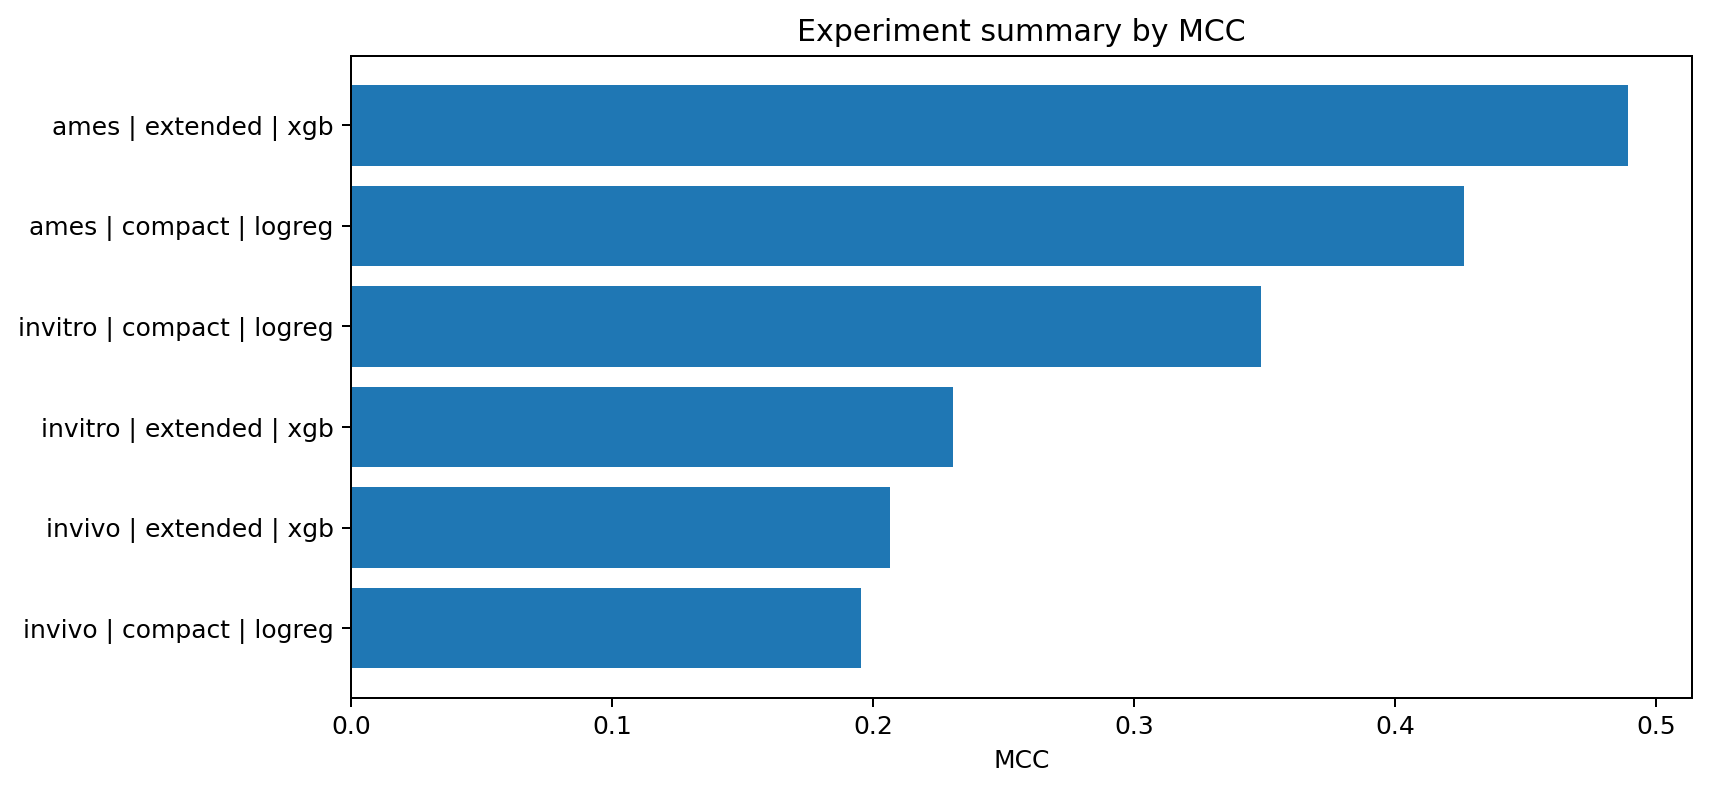

## Summary Balanced Accuracy

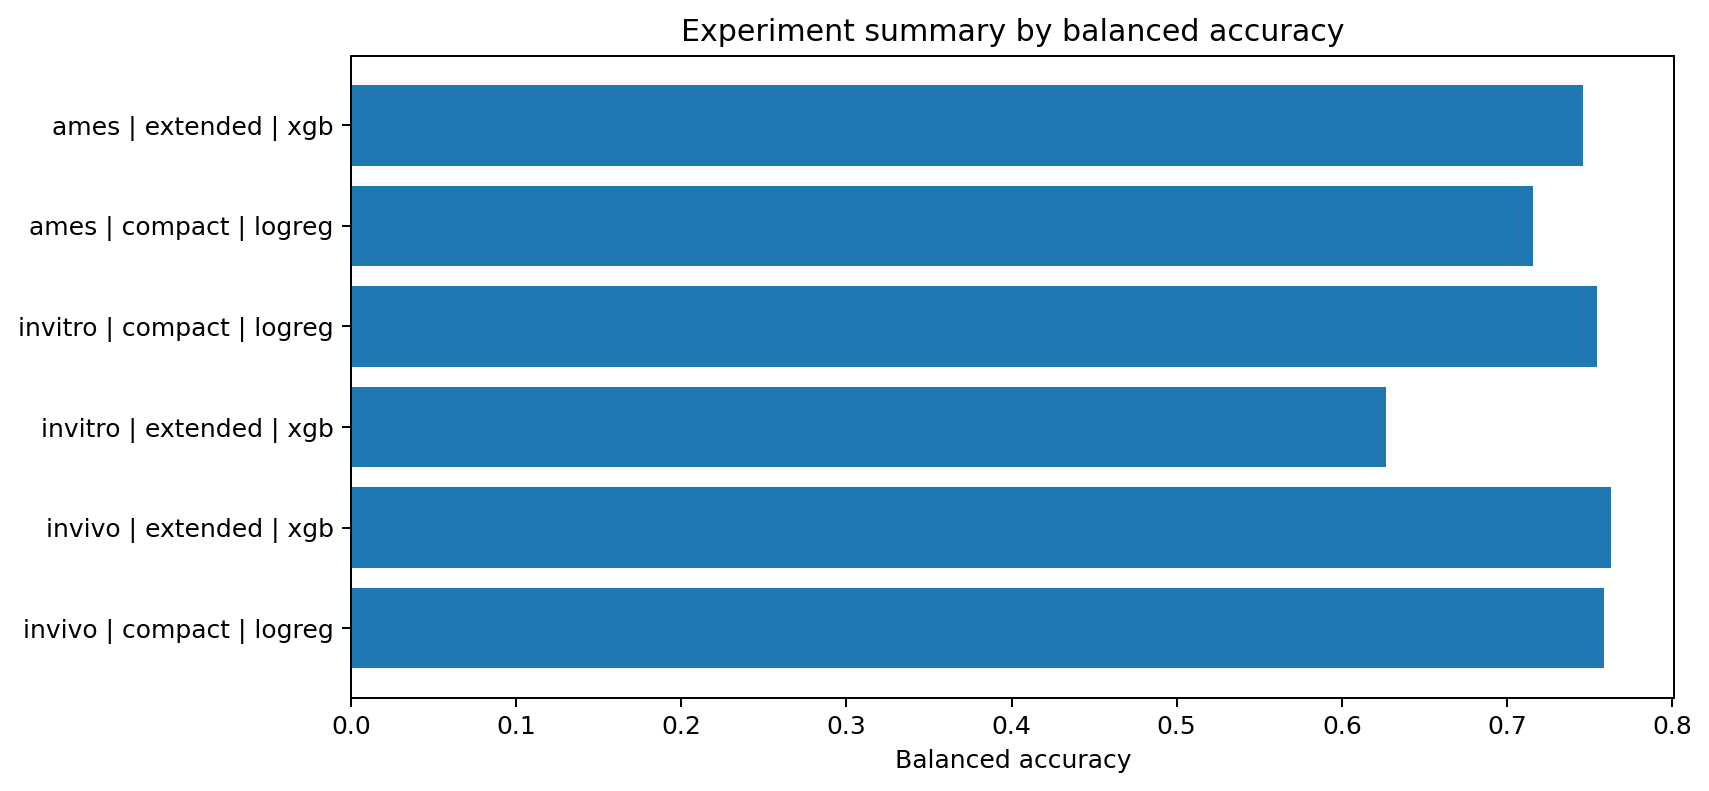

## Overview dashboard

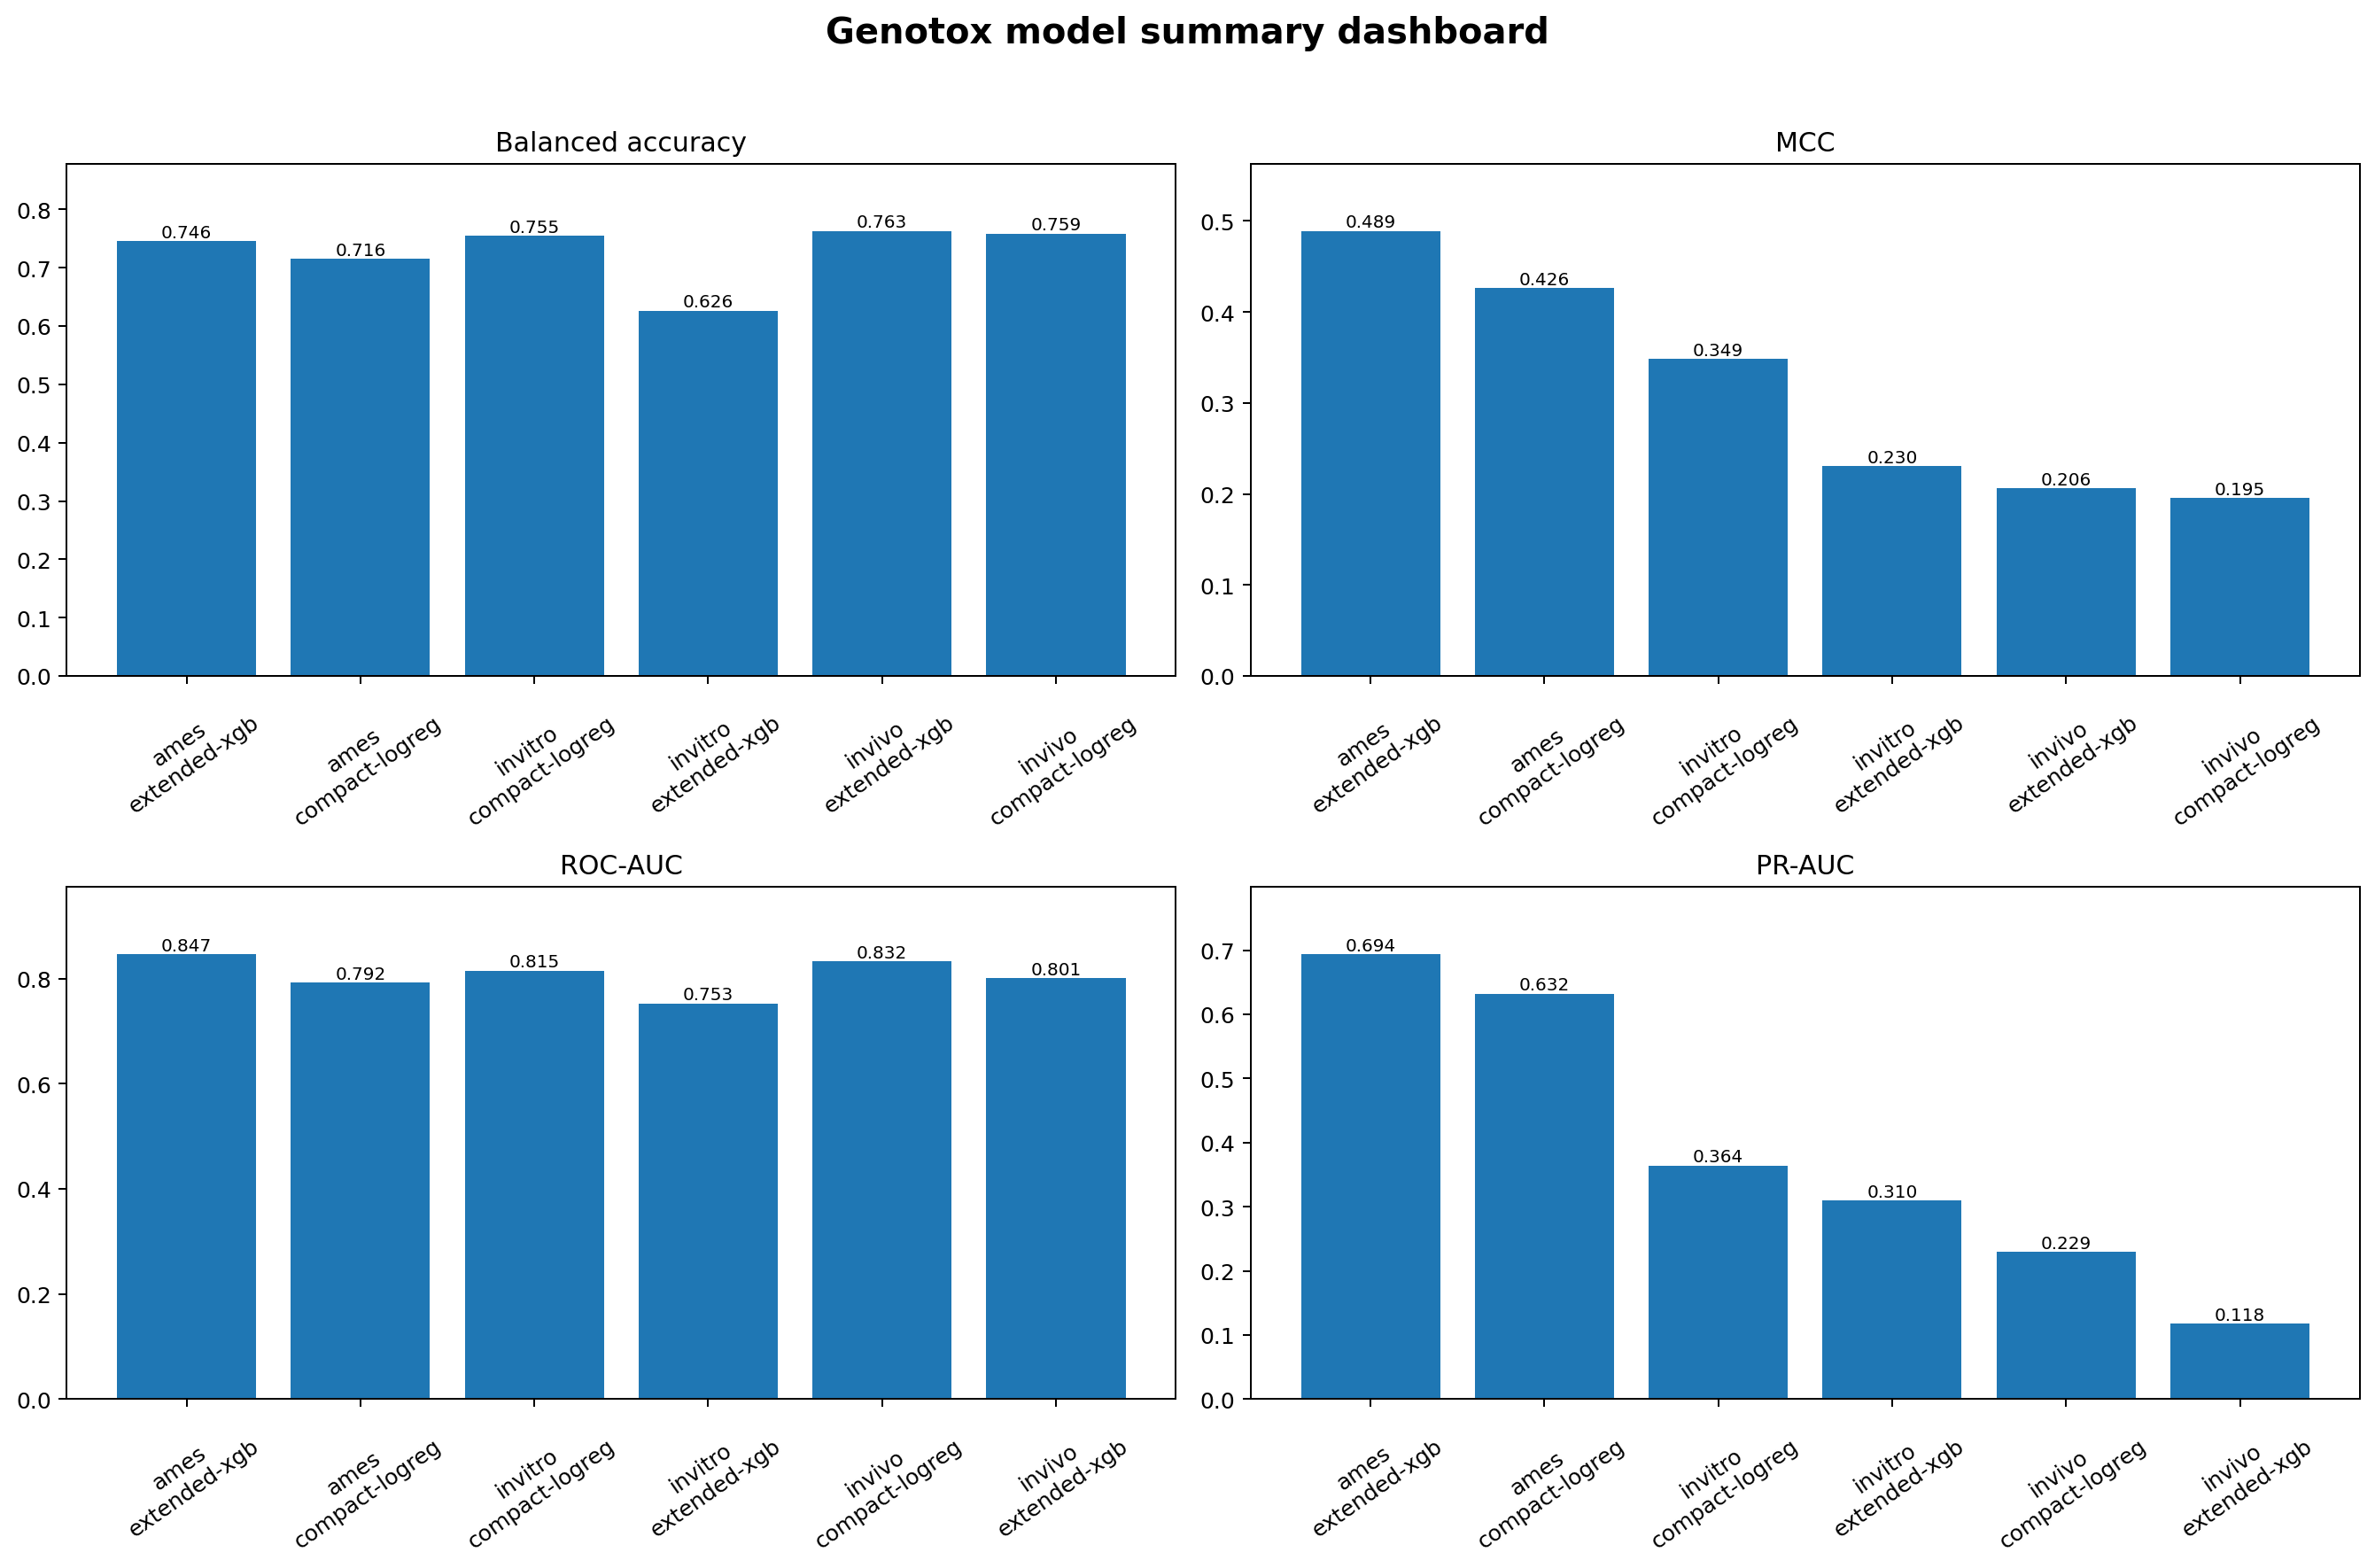

## Best artifact gallery

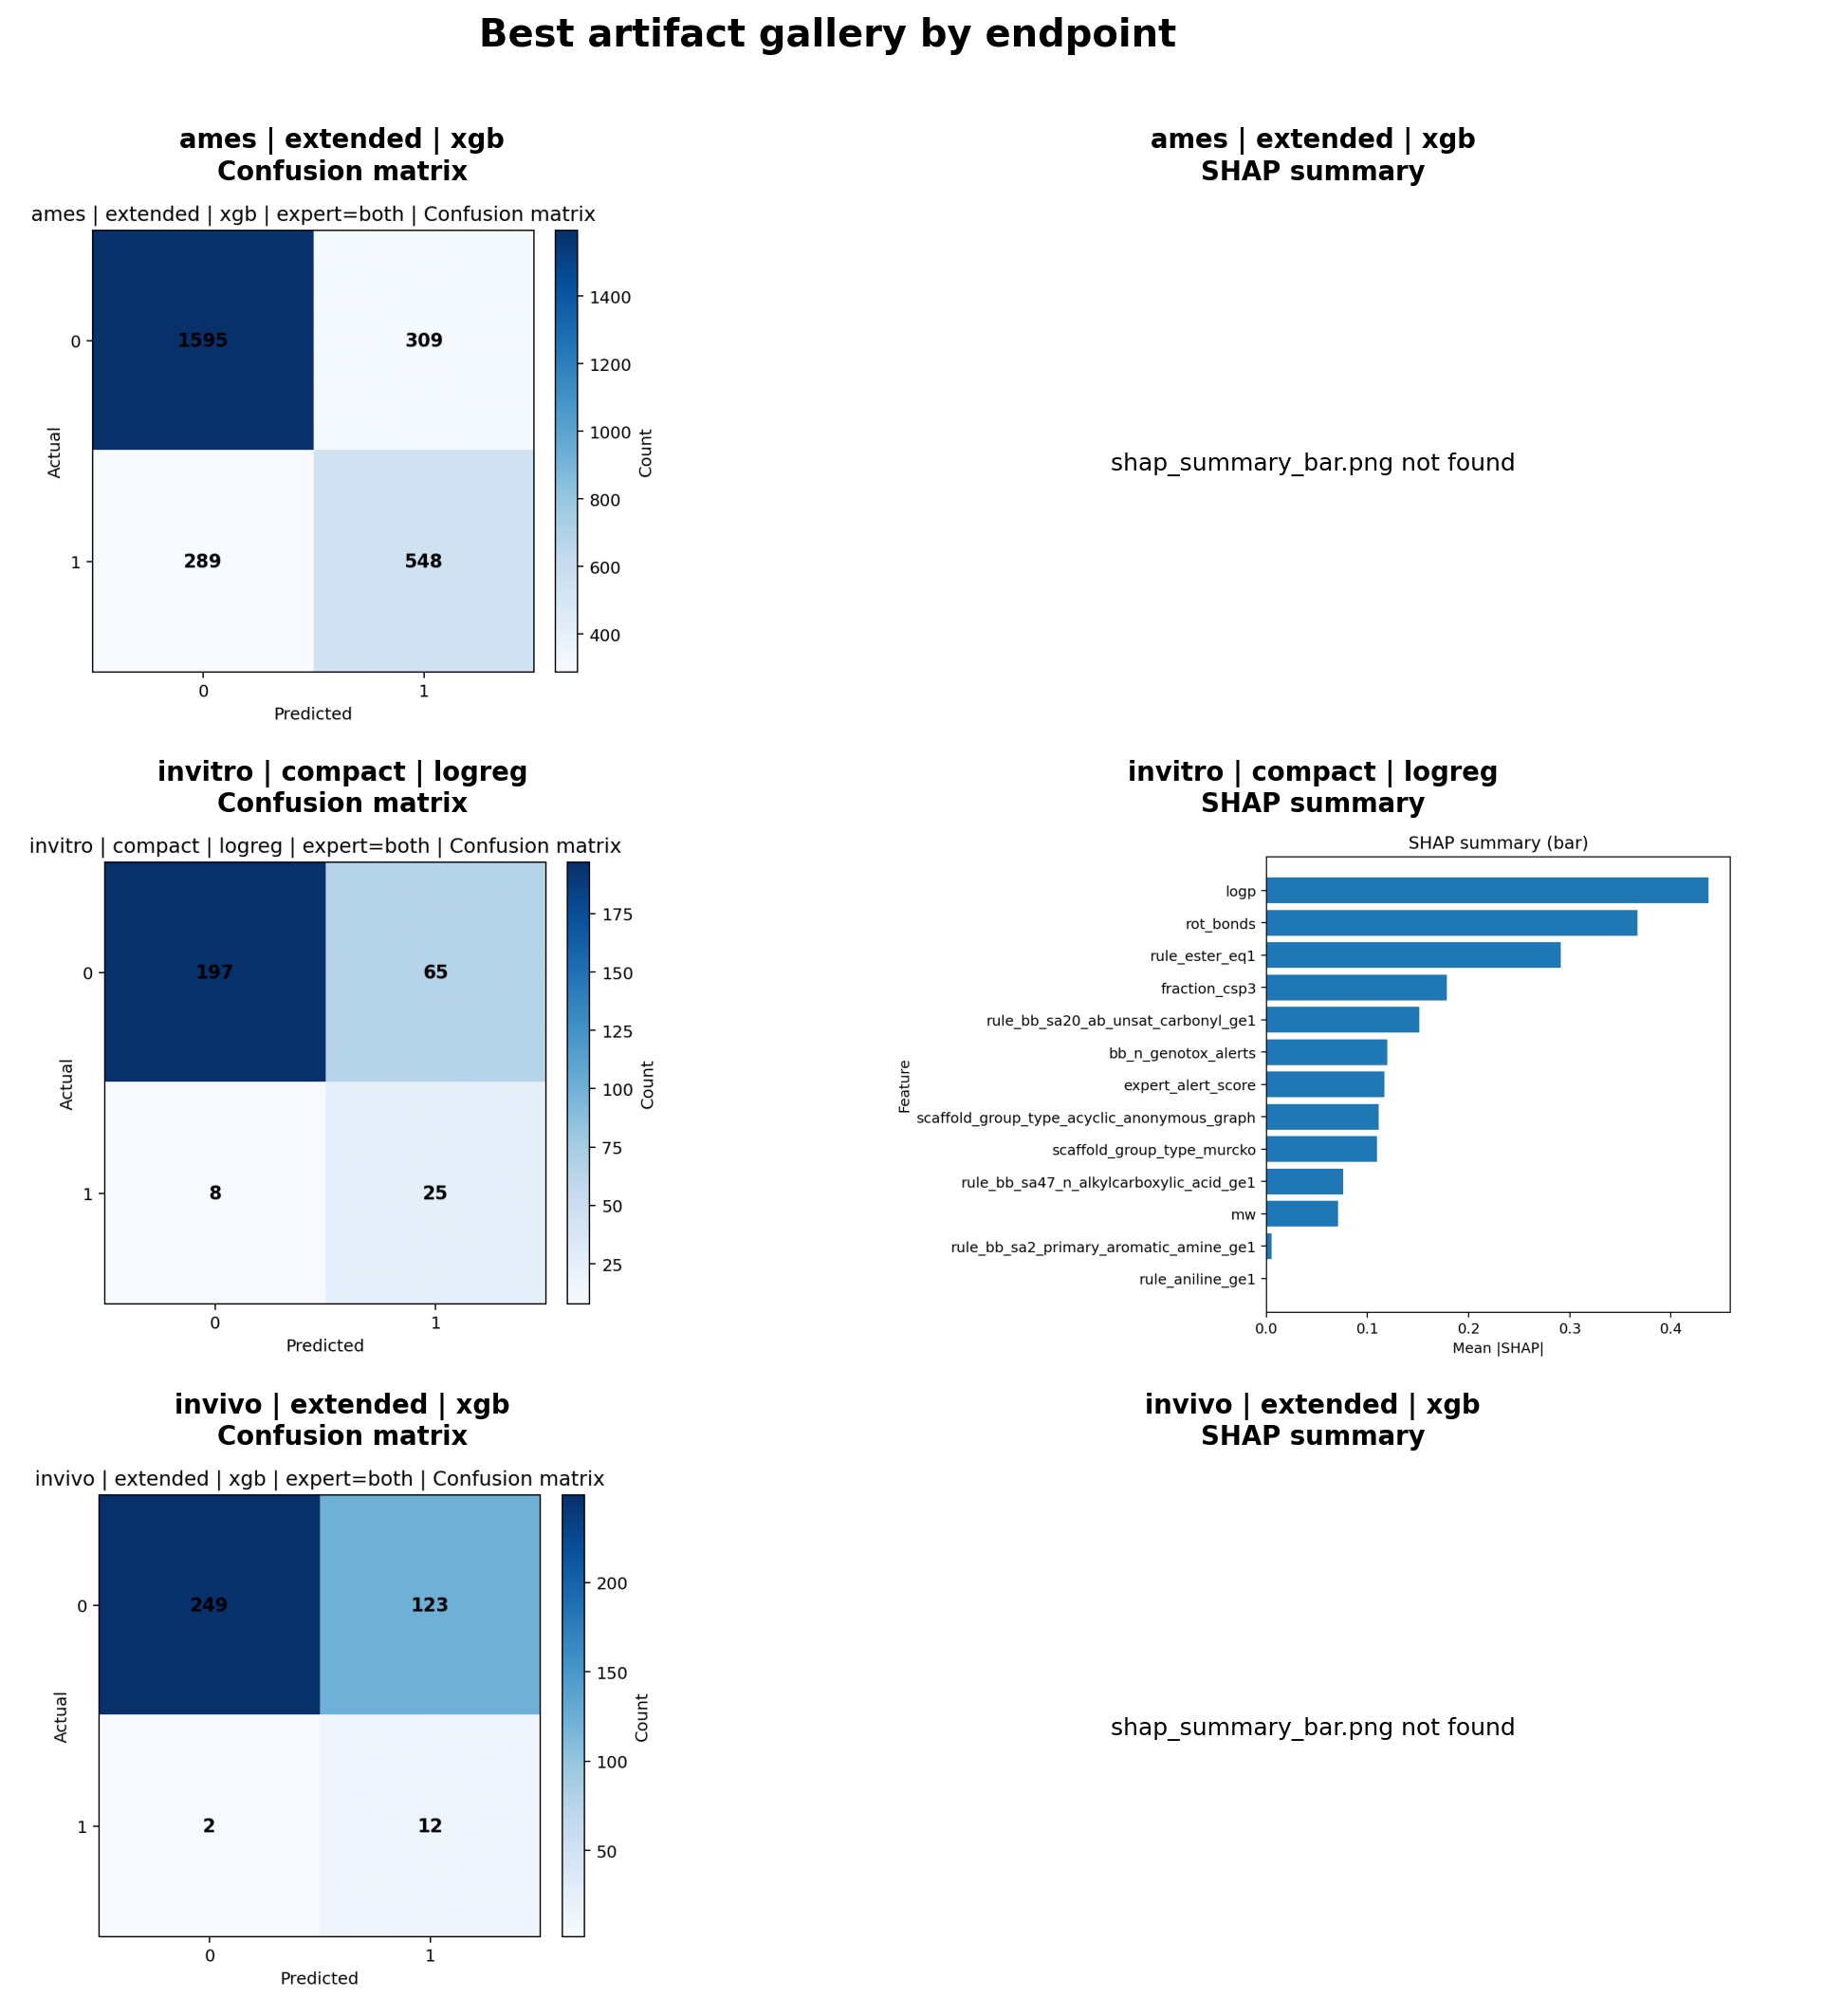

In [7]:
from IPython.display import display, Image, Markdown
from pathlib import Path

saved_dir = Path(SAVED_OUTDIR)
summary_csv = saved_dir / "summary_metrics.csv"
ranked_csv = saved_dir / "summary_metrics_ranked.csv"
best_csv = saved_dir / "best_by_endpoint.csv"

if ranked_csv.exists():
    print("summary_metrics_ranked.csv")
    display(pd.read_csv(ranked_csv).head(20))

best_df = pd.read_csv(best_csv) if best_csv.exists() else summary.sort_values(["endpoint", "mcc"], ascending=[True, False]).groupby("endpoint", as_index=False).first()

dashboard_path = create_summary_dashboard(summary, saved_dir)
gallery_path = create_best_artifact_gallery(best_df, saved_dir)

print("\nSaved dashboard:", dashboard_path)
print("Saved gallery  :", gallery_path)

if (saved_dir / "summary_mcc.png").exists():
    display(Markdown("## Summary MCC"))
    display(Image(filename=str(saved_dir / "summary_mcc.png")))
if (saved_dir / "summary_balanced_accuracy.png").exists():
    display(Markdown("## Summary Balanced Accuracy"))
    display(Image(filename=str(saved_dir / "summary_balanced_accuracy.png")))

display(Markdown("## Overview dashboard"))
display(Image(filename=str(dashboard_path)))

display(Markdown("## Best artifact gallery"))
display(Image(filename=str(gallery_path)))
